In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import re
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
# ========= path to train data
train_path = Path("/kaggle/input/competitions/hull-tactical-market-prediction/train.csv")
# ======== reading training data
ds_training = pd.read_csv(train_path)

#### Displaying first entries of the dataset: According to the competition documentation:
* date_id - An identifier for a single trading day.
* M* - Market Dynamics/Technical features.
* E* - Macro Economic features.
* I* - Interest Rate features.
* P* - Price/Valuation features.
* V* - Volatility features.
* S* - Sentiment features.
* MOM* - Momentum features.
* D* - Dummy/Binary features.
* forward_returns - The returns from buying the S&P 500 and selling it a day later. Train set only.
* risk_free_rate - The federal funds rate. Train set only.
* market_forward_excess_returns - Forward returns relative to expectations. Computed by subtracting the rolling five-year mean forward returns and winsorizing the result using a median absolute deviation (MAD) with a criterion of 4. Train set only.

In [4]:
ds_training.head(5)

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
0,0,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002421,0.000301,-0.003038
1,1,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008495,0.000303,-0.009114
2,2,0,0,0,1,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009624,0.000301,-0.010243
3,3,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004662,0.000299,0.004046
4,4,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.011686,0.000299,-0.012301


#### Checking how many columns are from each group (defined above)

In [5]:
groups = ["M", "E", "I", "P", "V", "S", "MOM","D",
         "forward_returns", "risk_free_rate", 	"market_forward_excess_returns"]
columns = ds_training.columns

prefixes = [re.match(r"[A-Za-z_]+", col).group() for col in columns]

number_groups = Counter(prefixes)

#  only want counts restricted to predefined groups list:
number_groups = {g: number_groups.get(g, 0) for g in groups}
number_groups

{'M': 18,
 'E': 20,
 'I': 9,
 'P': 13,
 'V': 13,
 'S': 12,
 'MOM': 0,
 'D': 9,
 'forward_returns': 1,
 'risk_free_rate': 1,
 'market_forward_excess_returns': 1}

#### For each one of this groups, check what is the data type, missing values, number of total values, distribution over time

                               n_cols  pct_missing_mean  pct_missing_max
group                                                                   
D                                   9              0.00             0.00
E                                  20             15.18            77.02
I                                   9             11.12            11.12
M                                  18             25.33            61.31
P                                  13             12.66            18.10
S                                  12             20.11            63.36
V                                  13             19.70            66.85
forward_returns                     1              0.00             0.00
market_forward_excess_returns       1              0.00             0.00
risk_free_rate                      1              0.00             0.00


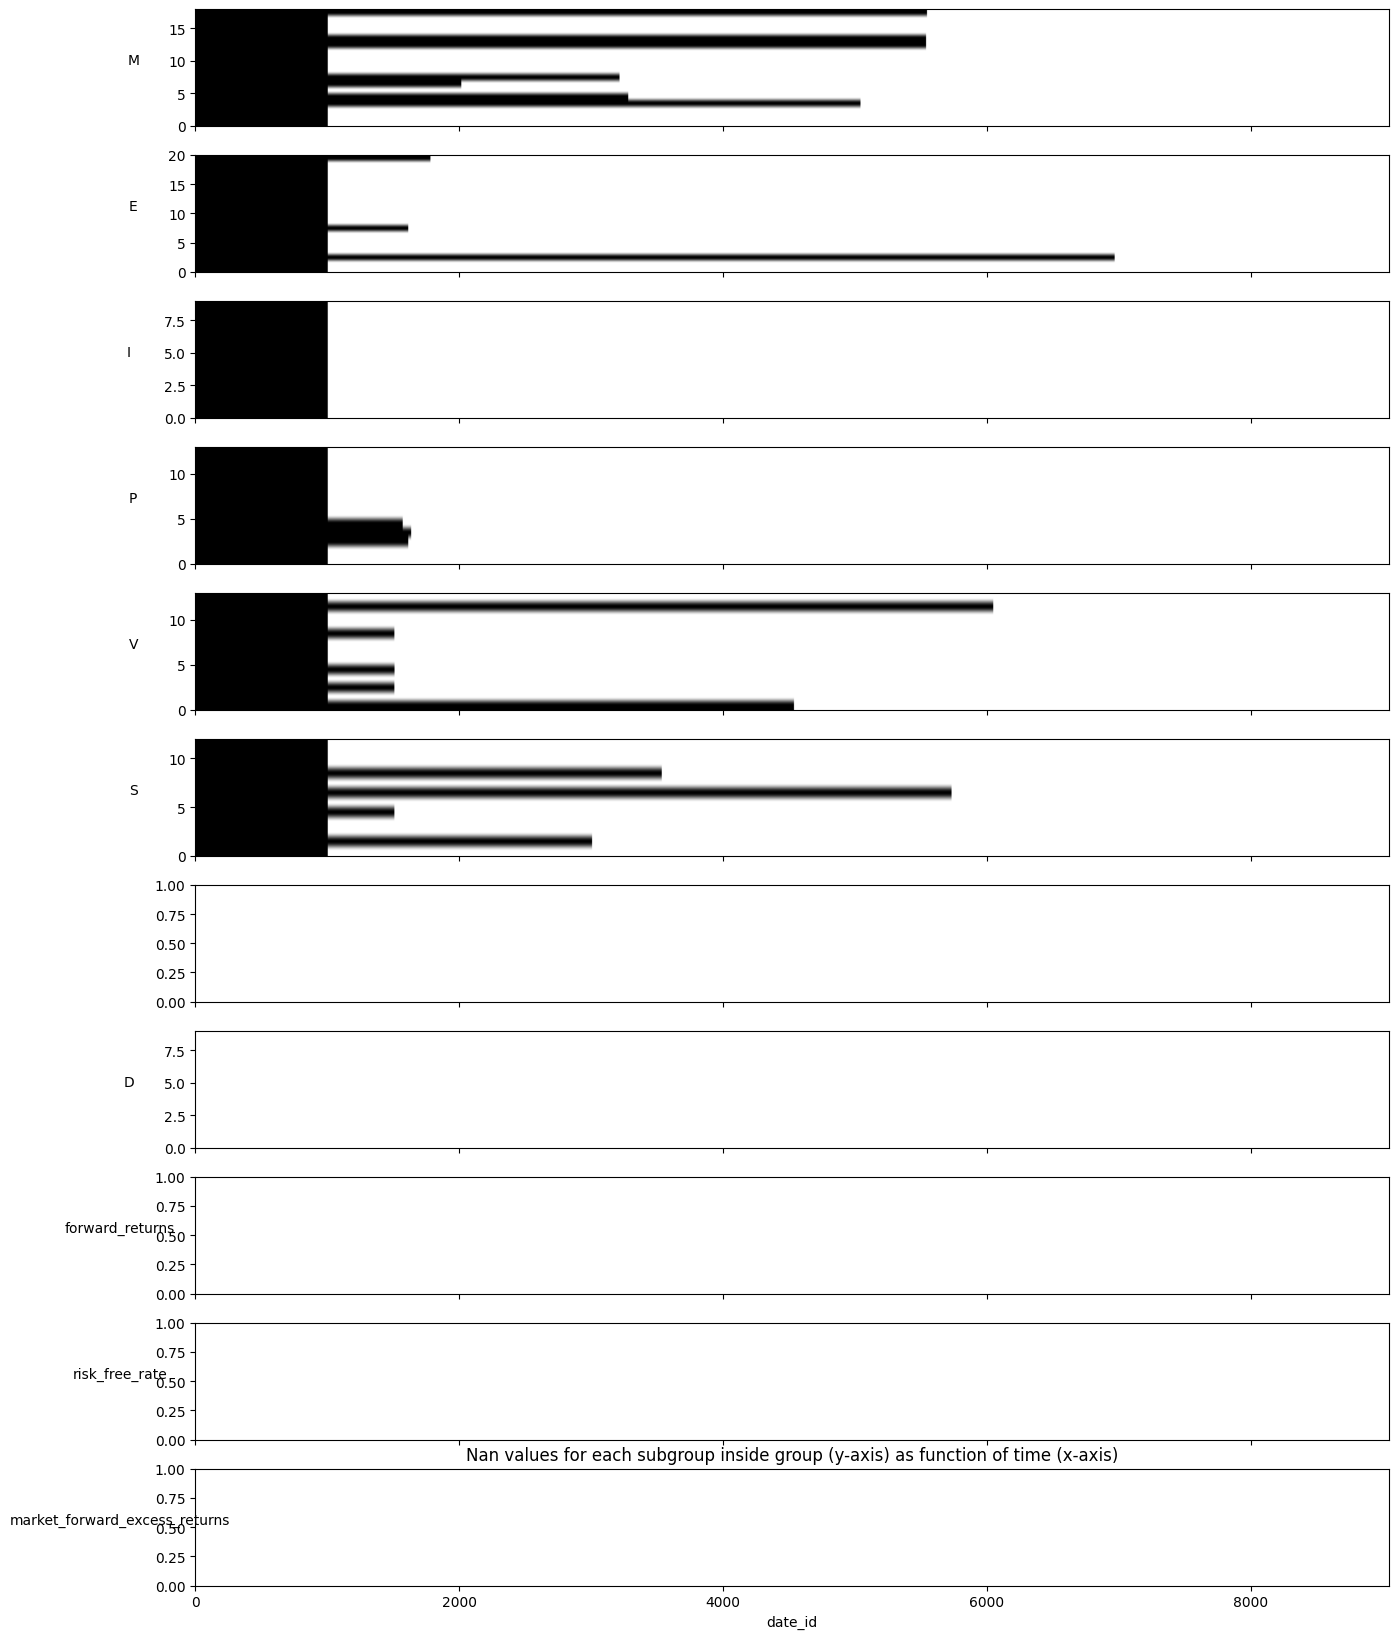

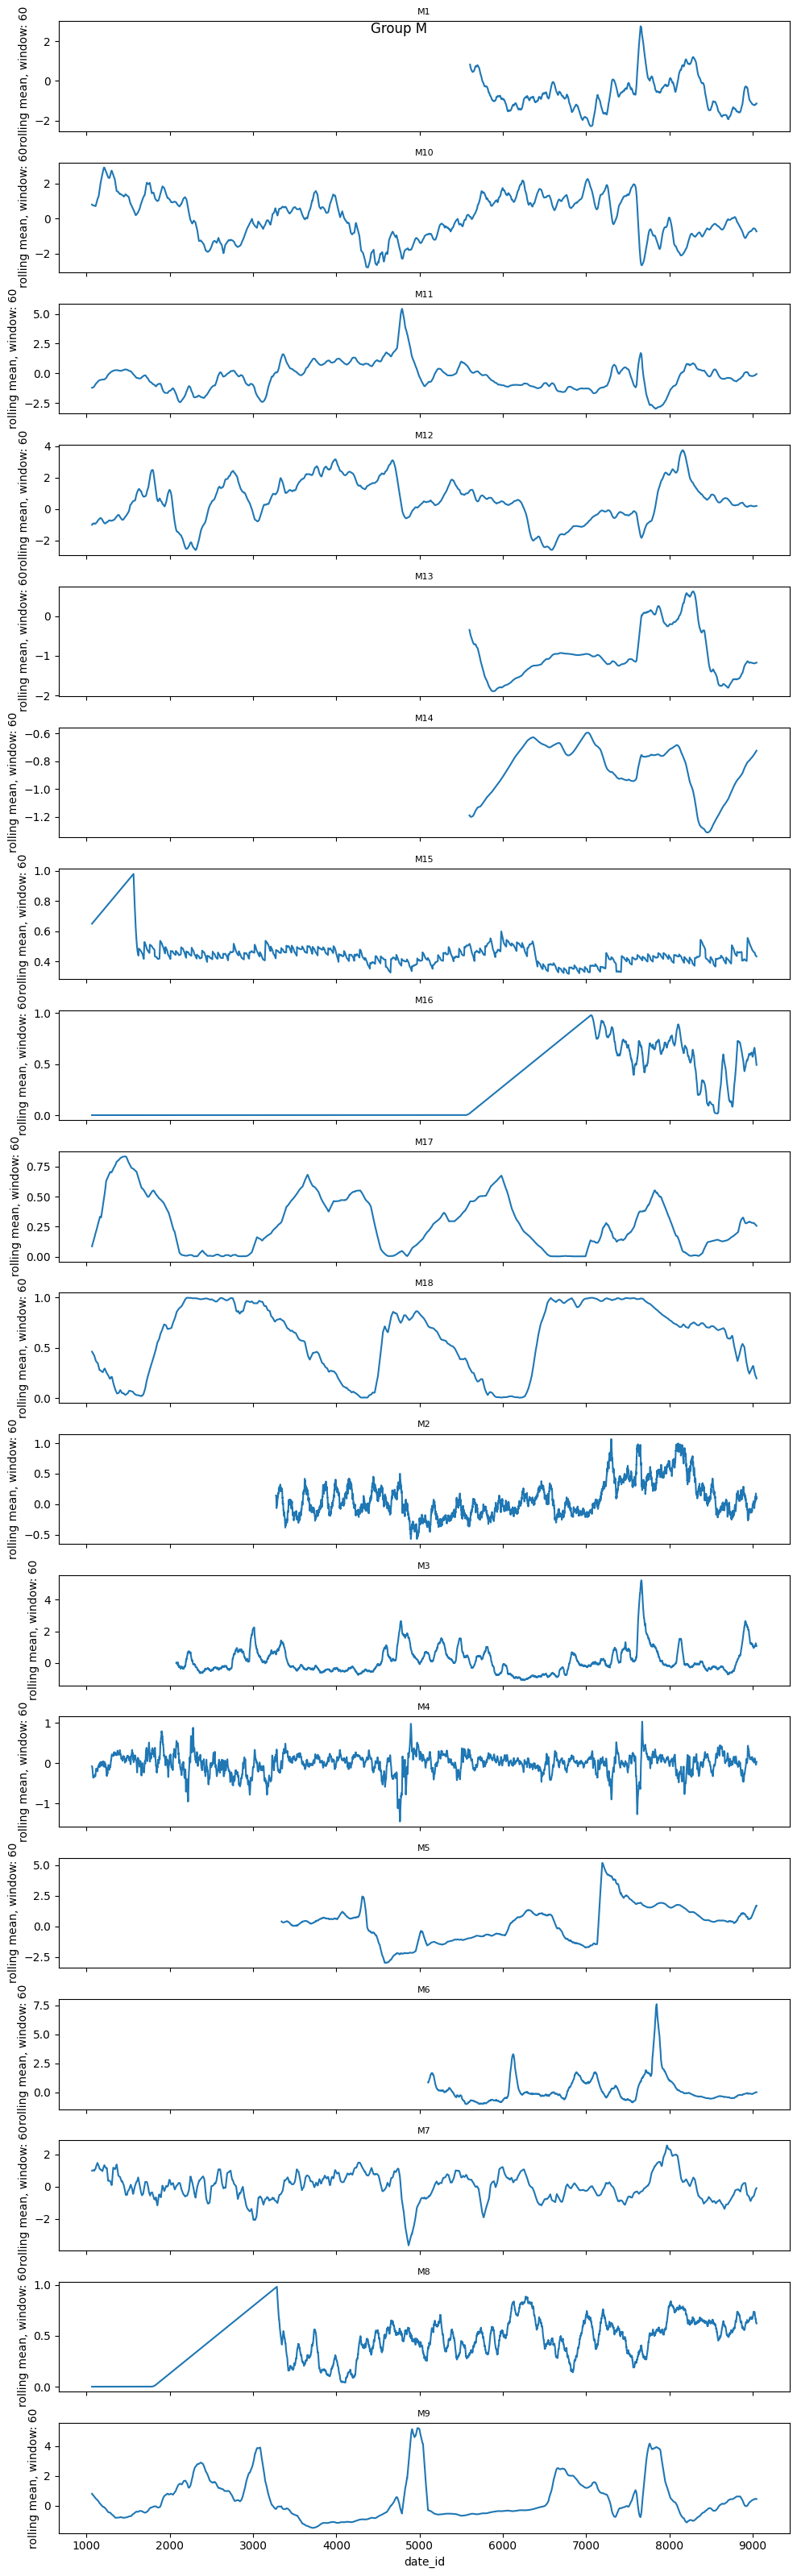

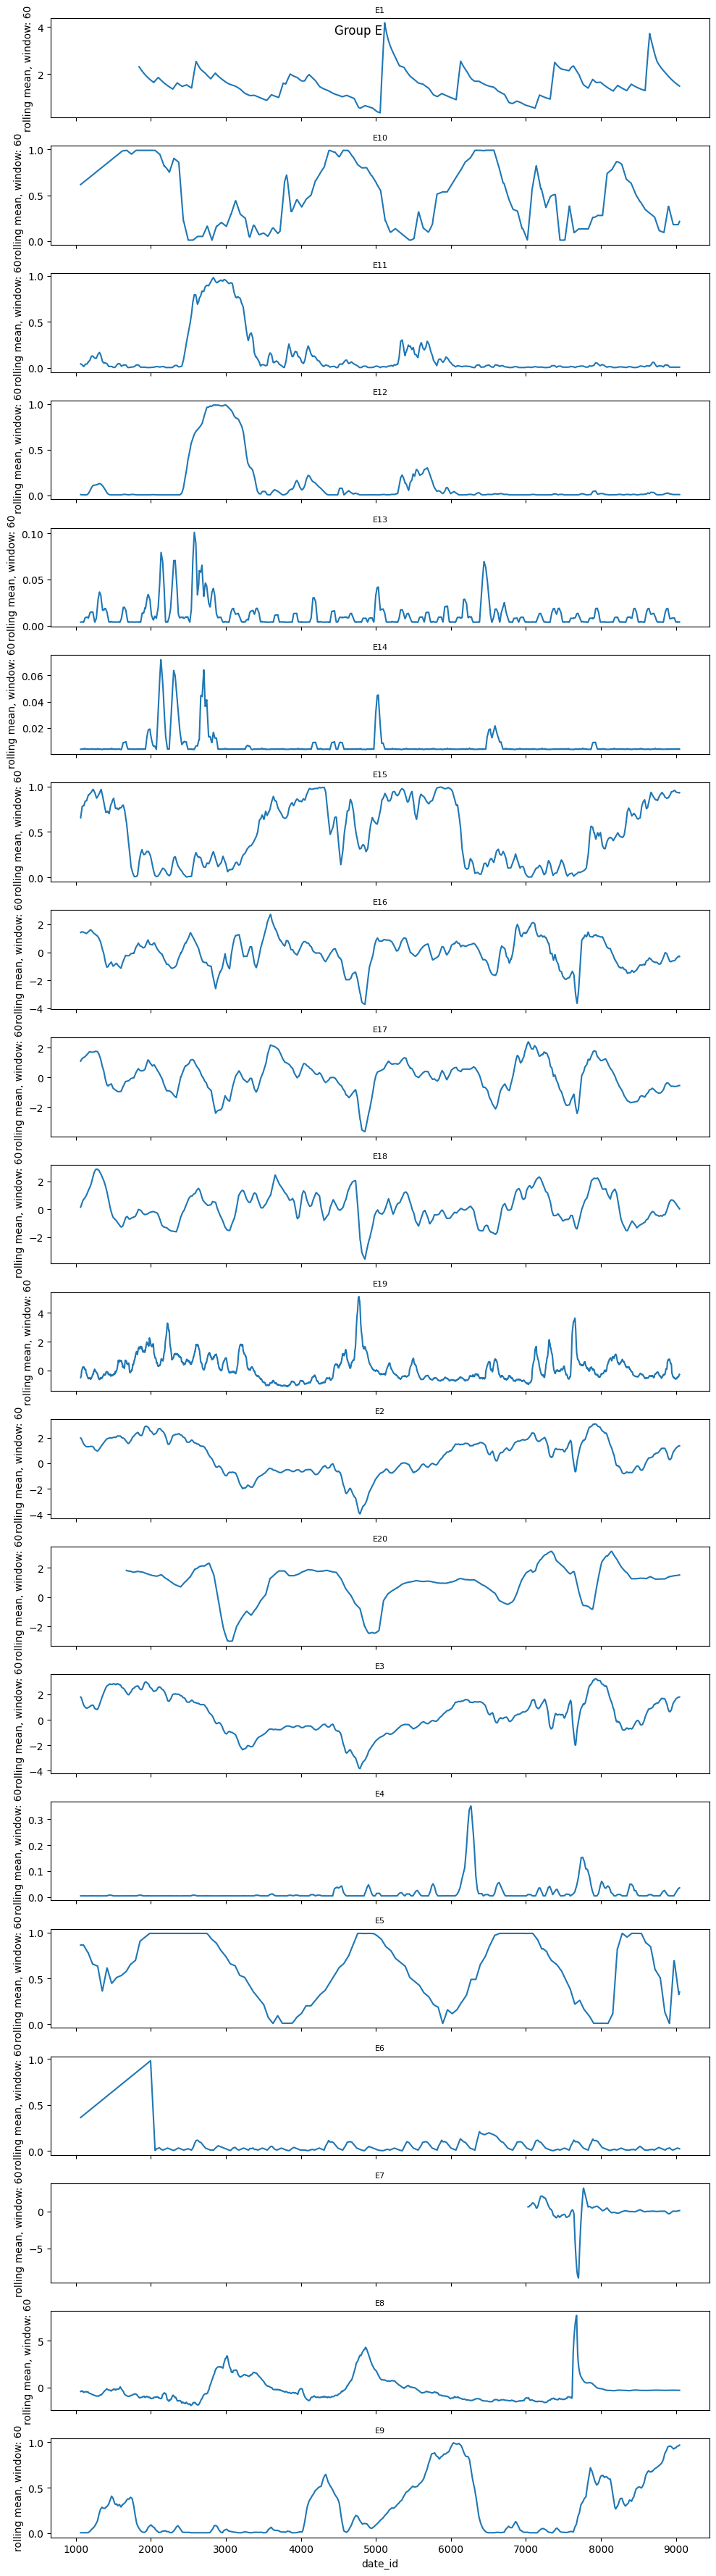

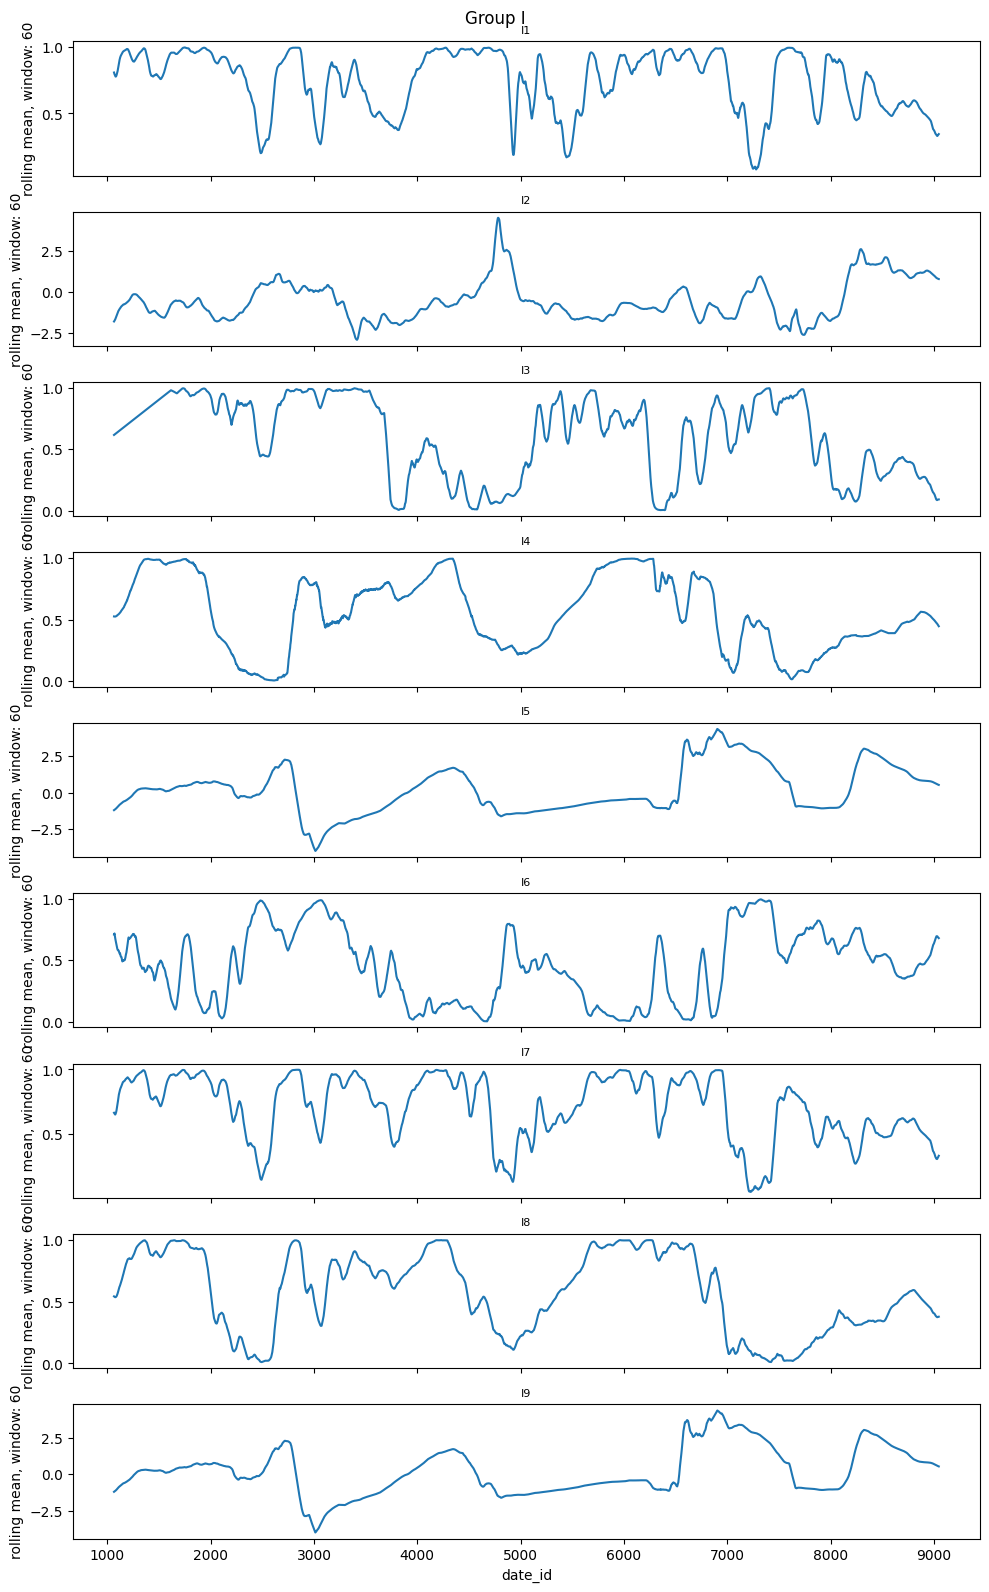

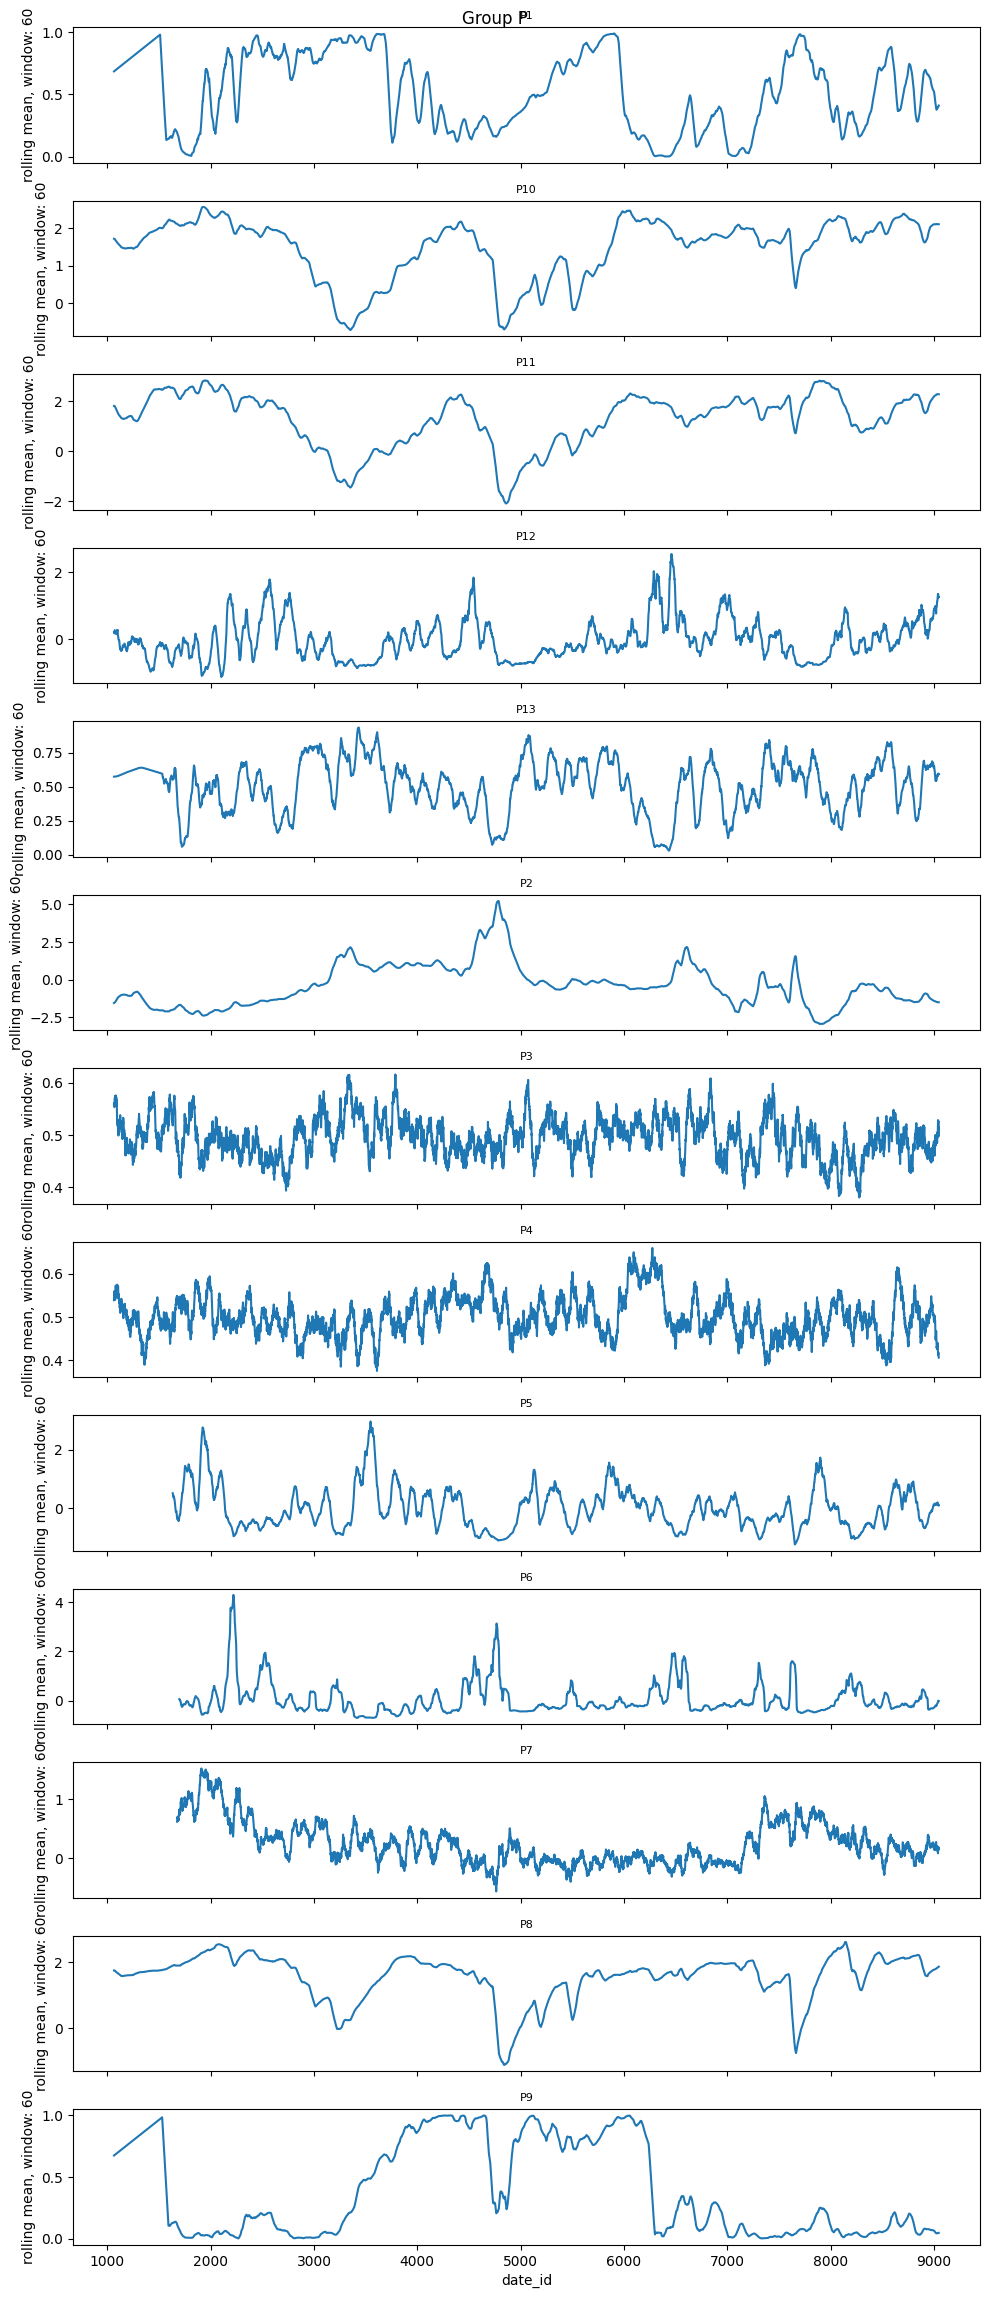

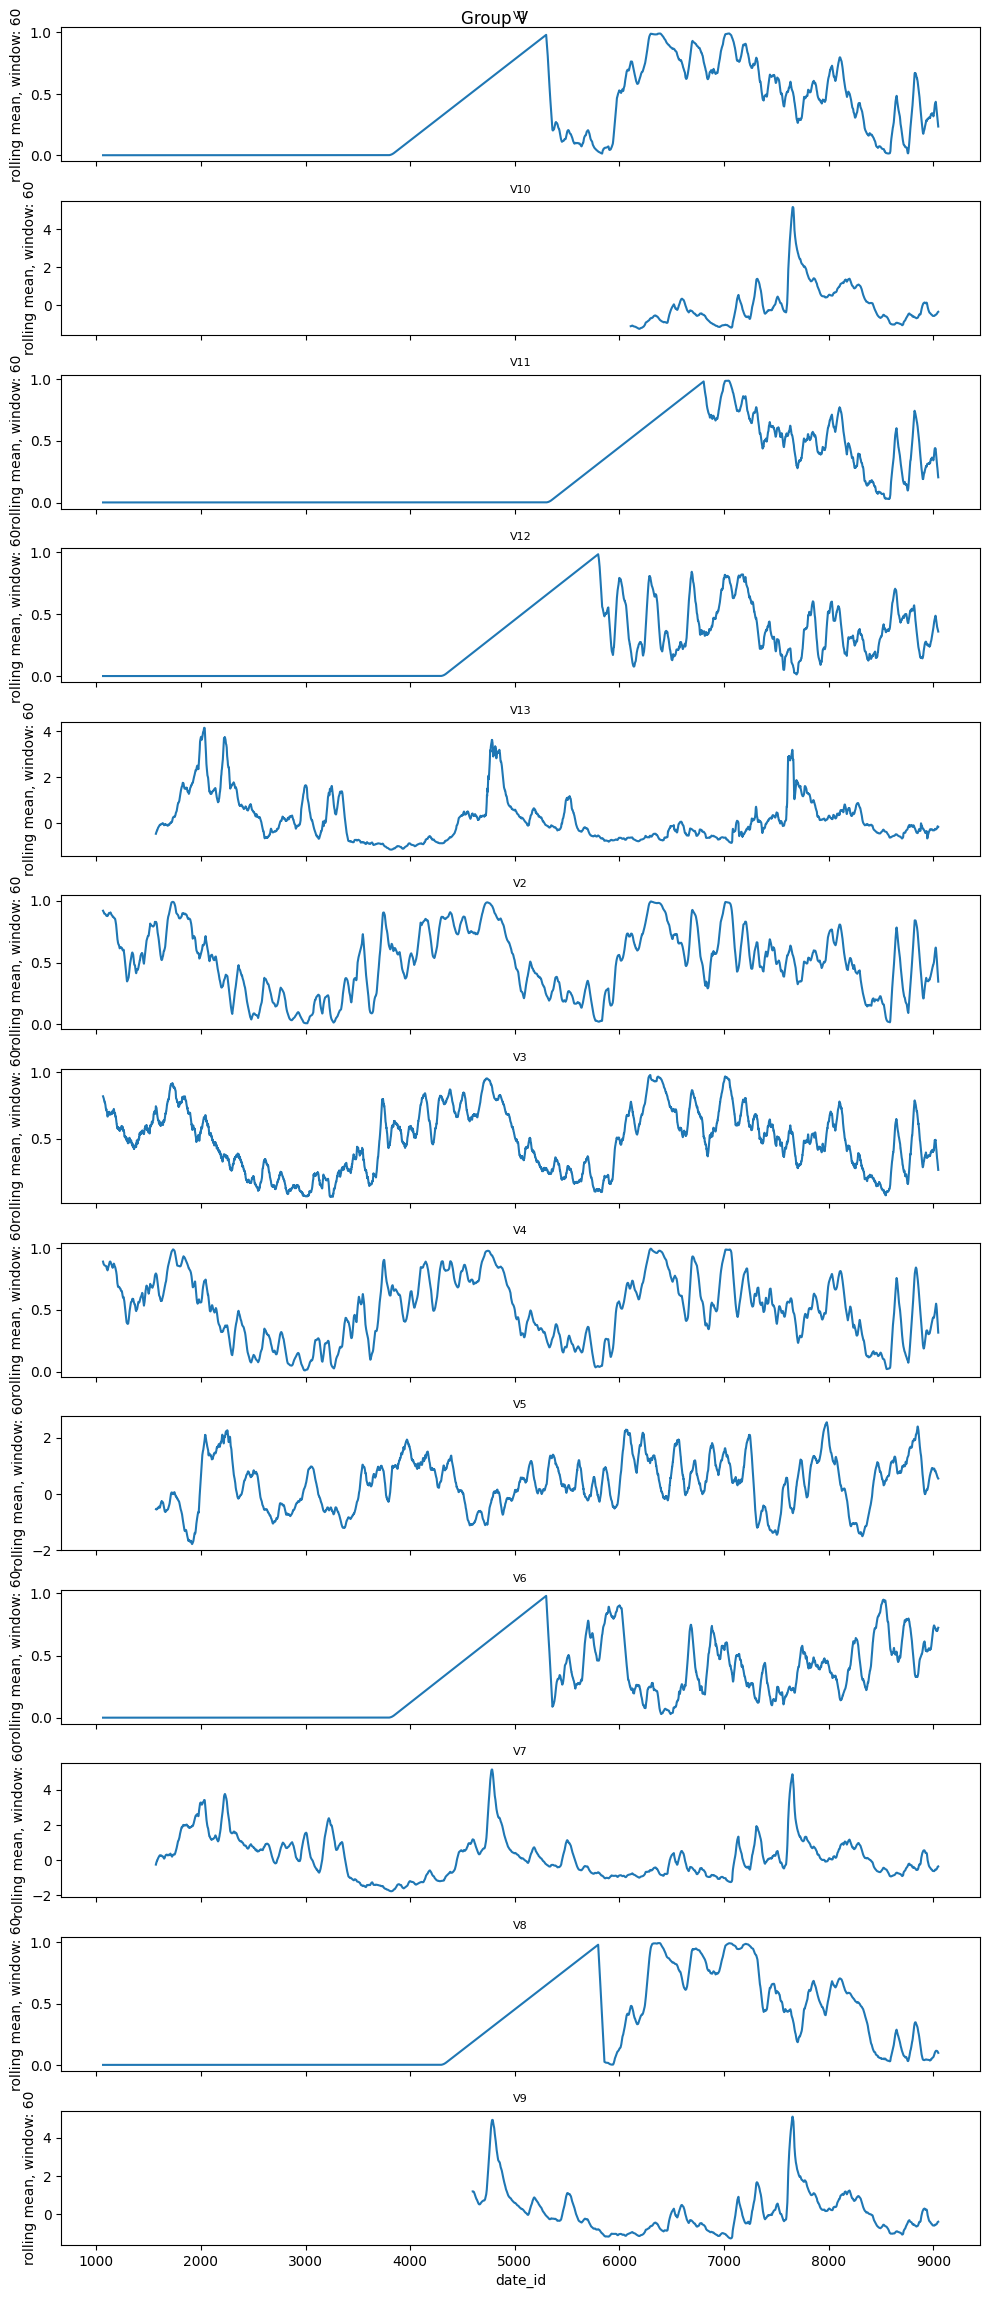

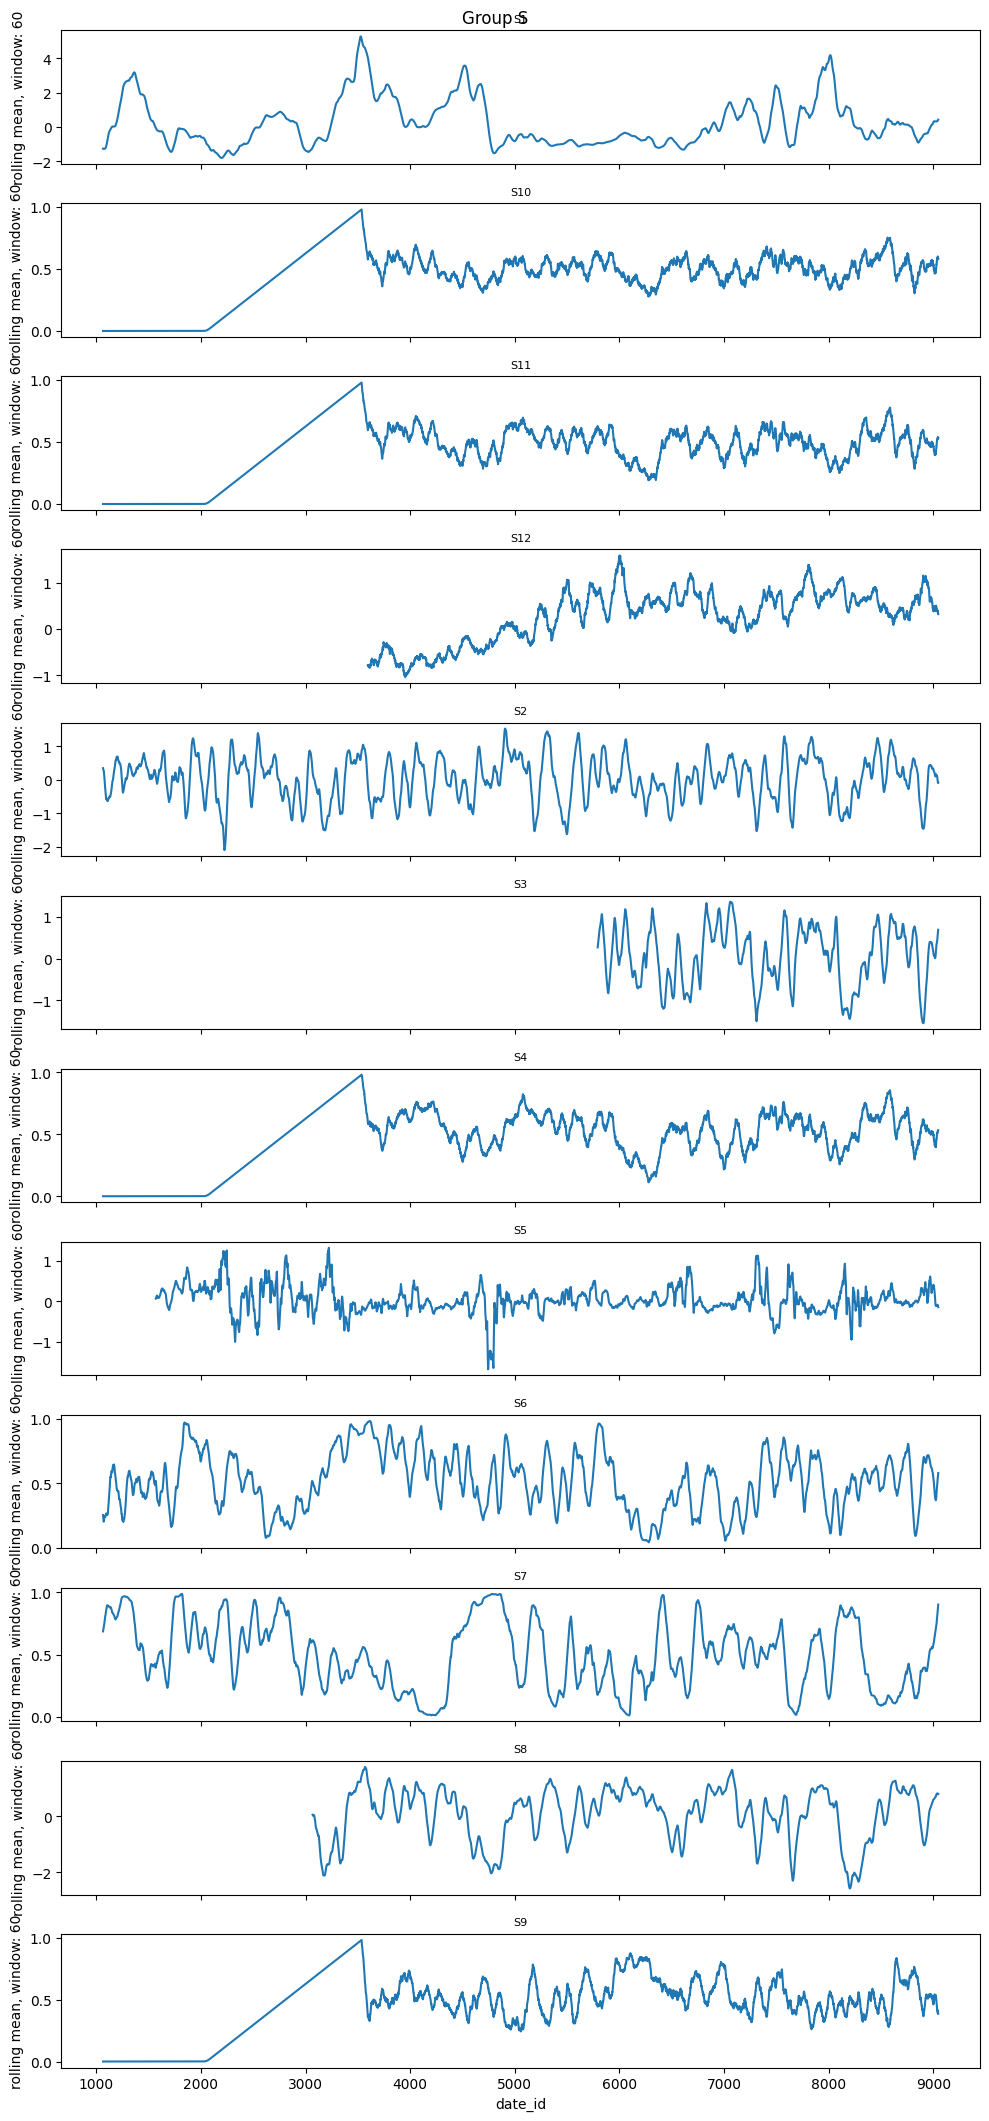

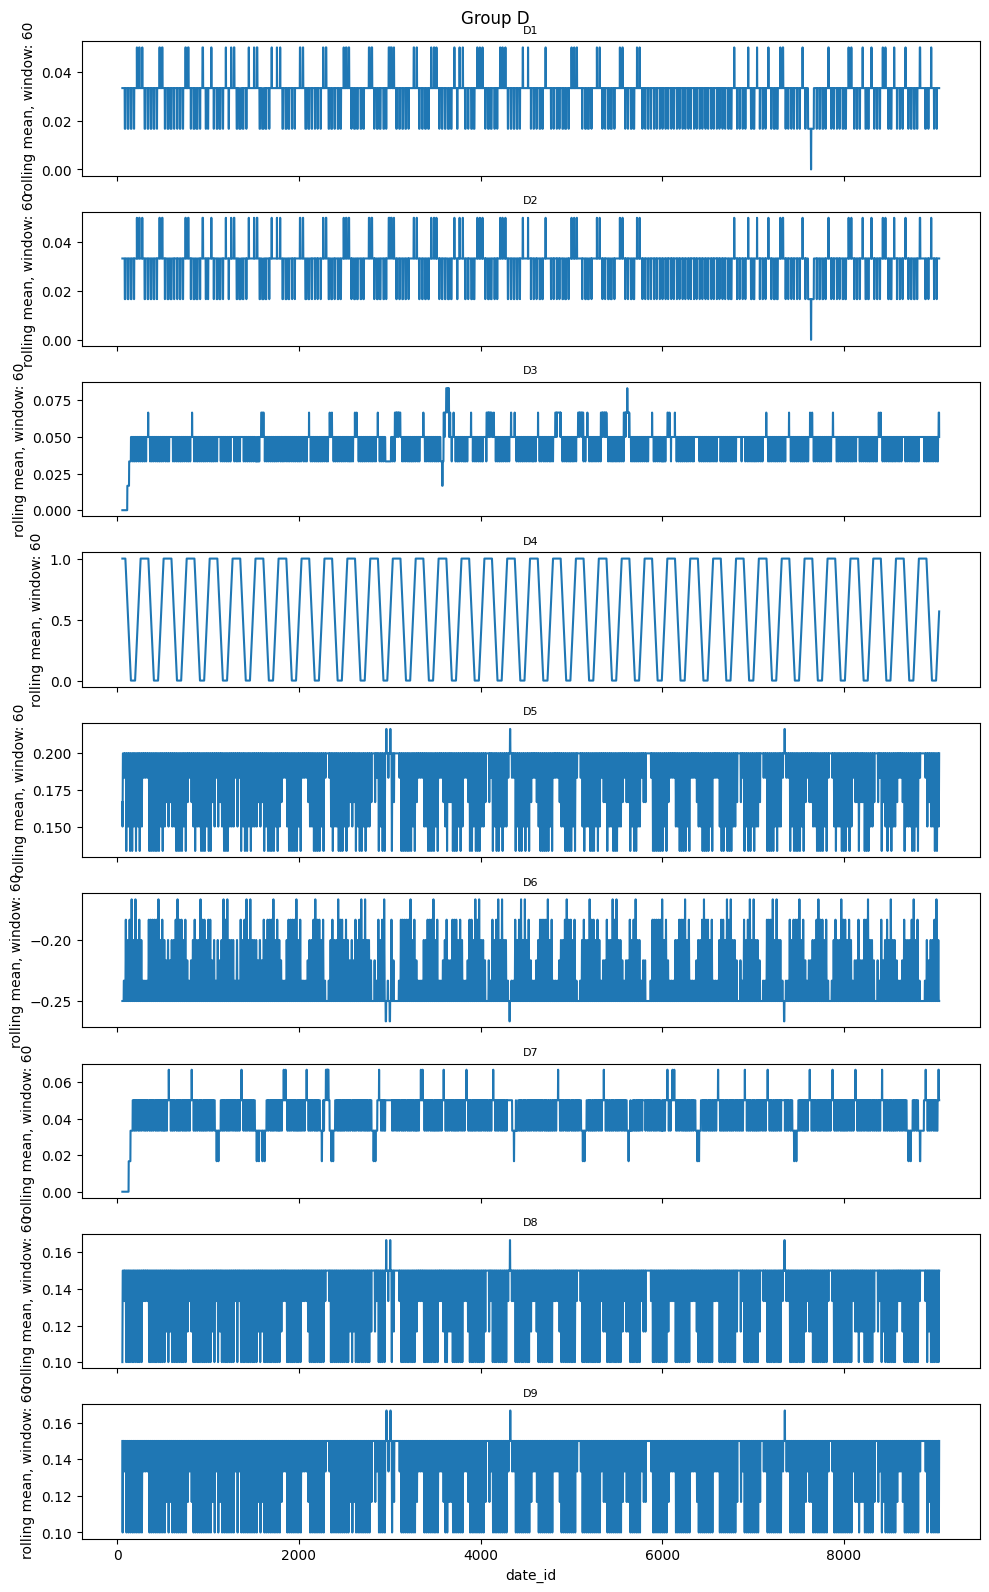

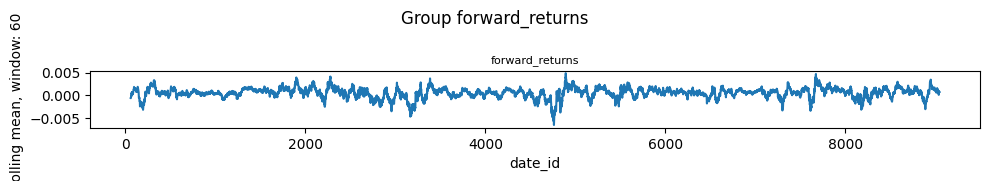

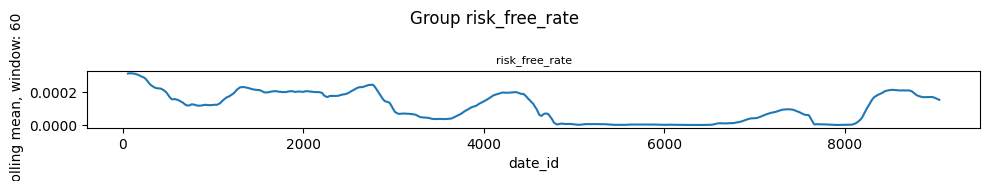

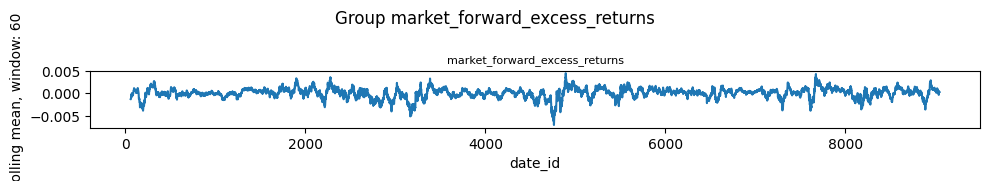

In [6]:
cols = [c for c in ds_training.columns if c != "date_id"] #takes all columns except date_id
prefix = lambda c: re.match(r"[A-Za-z_]+", c).group() #function to obtain the group
group_of = {c: prefix(c) for c in cols} #associates each col with a group
group_cols = {g: [c for c in cols if group_of[c] == g] for g in groups}#takes all columns belonging
                #to the same group, e.g. {'M': ['M1','M10','M11'],...
detail = pd.DataFrame({"column": cols, "group": [group_of[c] for c in cols]})# creates a dataset
                #with column and the associated group

detail["dtype"] = ds_training[cols].dtypes.values #new column with dtype
detail["n_missing"] = ds_training[cols].isna().sum().values #number of nan values for each column over time
detail["pct_missing"] = (detail["n_missing"] / len(ds_training) * 100).round(2)#percentage of nan
detail["n_unique"] = ds_training[cols].nunique().values#what are the unique values for each column
detail["first_valid_date"] = [
    ds_training.loc[ds_training[c].first_valid_index(), "date_id"]
    if ds_training[c].first_valid_index() is not None else np.nan
    for c in cols
] #returns the first validate date index if there is not anything, it returns nan

detail["last_valid_date"] = [
    ds_training.loc[ds_training[c].last_valid_index(), "date_id"]
    if ds_training[c].last_valid_index() is not None else np.nan
    for c in cols
] #returns the last valid date index

detail = detail.merge(ds_training[cols].describe().T[["mean", "std", "min", "max"]],
                       left_on="column", right_index=True) #Computes statistics for each column
    #keeps only "mean", "std",... and then merge this with detail

# --- per-group summary ---
summary = detail.groupby("group").agg(
    n_cols=("column", "count"), #counts how many columns has each group
    pct_missing_mean=("pct_missing", "mean"), #compute the mean for that group for "pct_missing"
    pct_missing_max=("pct_missing", "max"), #computes the max of that group for "pct_missing"
).round(2)
print(summary)

# --- missingness heatmap over time, per group ---
fig, axes = plt.subplots(len(groups), 1, figsize=(14, 1.5 * len(groups)), sharex=True)
for ax, g in zip(axes, groups):
    gcols = group_cols[g]#access to the columns in that group
    if not gcols:
        continue
    ax.imshow(ds_training[gcols].isna().T, aspect="auto", cmap="gray_r",
               extent=[ds_training["date_id"].min(), ds_training["date_id"].max(), 0, len(gcols)])
    ax.set_ylabel(g, rotation=0, labelpad=25)
plt.xlabel("date_id")
plt.tight_layout()
plt.title("Nan values for each subgroup inside group (y-axis) as function of time (x-axis)")
plt.show()

# --- distribution over time (rolling mean per column, faceted by group) ---
window = 60
for g in groups:
    gcols = group_cols[g]
    if not gcols:
        continue
    n = len(gcols) #number of columns in each group
    fig, axes = plt.subplots(n, 1, figsize=(10, 1.8 * n), sharex=True)
    axes = np.atleast_1d(axes) #in case of scalar, it is converted to array
    for ax, c in zip(axes, gcols):
        #makes a rollin mean of every 60 time steps
        ds_training.set_index("date_id")[c].rolling(window).mean().plot(ax=ax)
        ax.set_title(c, fontsize=8)
        ax.set_ylabel(f"rolling mean, window: {window}")
    plt.suptitle(f"Group {g}")
    
    plt.tight_layout()
    plt.show()

### Observation: This set of figures shows that the groups of variables M, E, I, P, V, and S do not present data for the first $\approx$ 1000 time steps. Furthermore, some variables within these groups have even larger gaps, for example, S3, which only has measurements from time step $\approx$ 6000 onward. Additionally, once a variable begins presenting data at a given time step, there are no further gaps. Based on this observation, it is necessary to decide how to proceed with these data.

#### Ideas:

1. Crop the data to the point where most variables start, and for variables that start later, fill the missing values with 0, adding a new column data_present that indicates whether a given 0 comes from a real measurement or from the absence of data. **Observation** LightGBM/XGBoost/CatBoost`don't require this 0 handling as they manage NaN values natively
2. Use the whole time period and handle the gaps the same way as in option 1.

### Note: Why not use another imputation method at this stage? I will start with this "clean" approach and check performance. Later, I can explore imputing the gapped variables using highly correlated variables that do not have the gap.

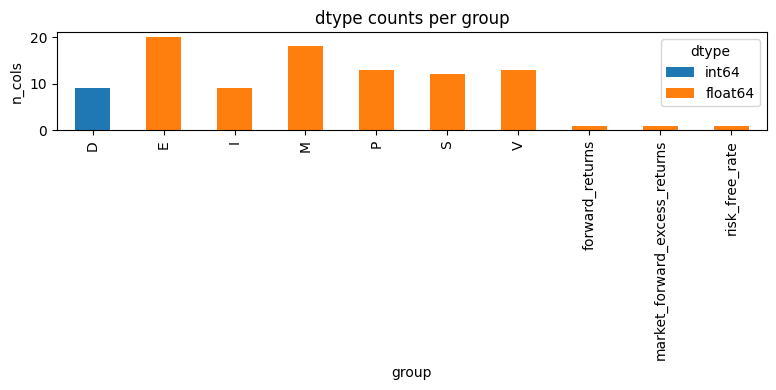

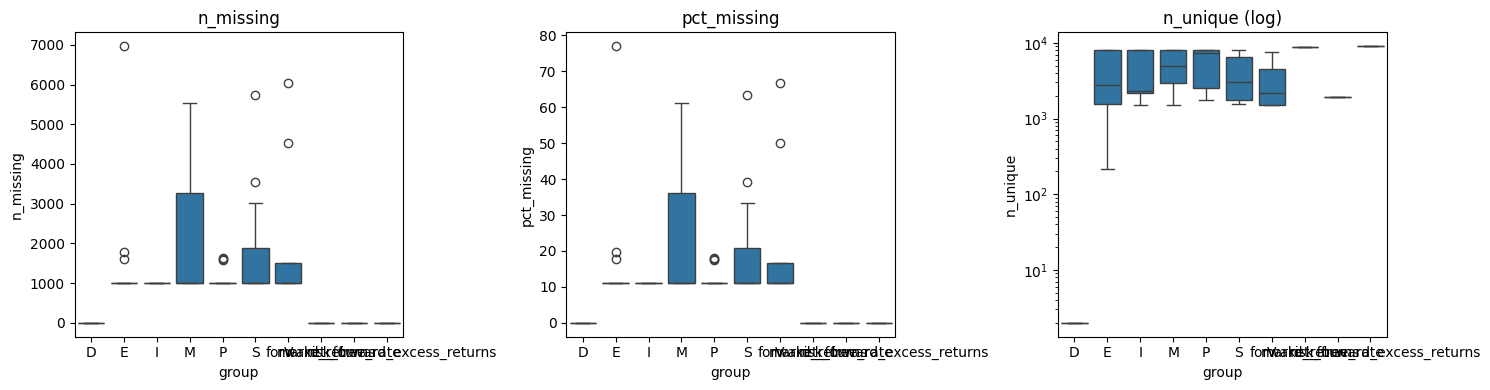

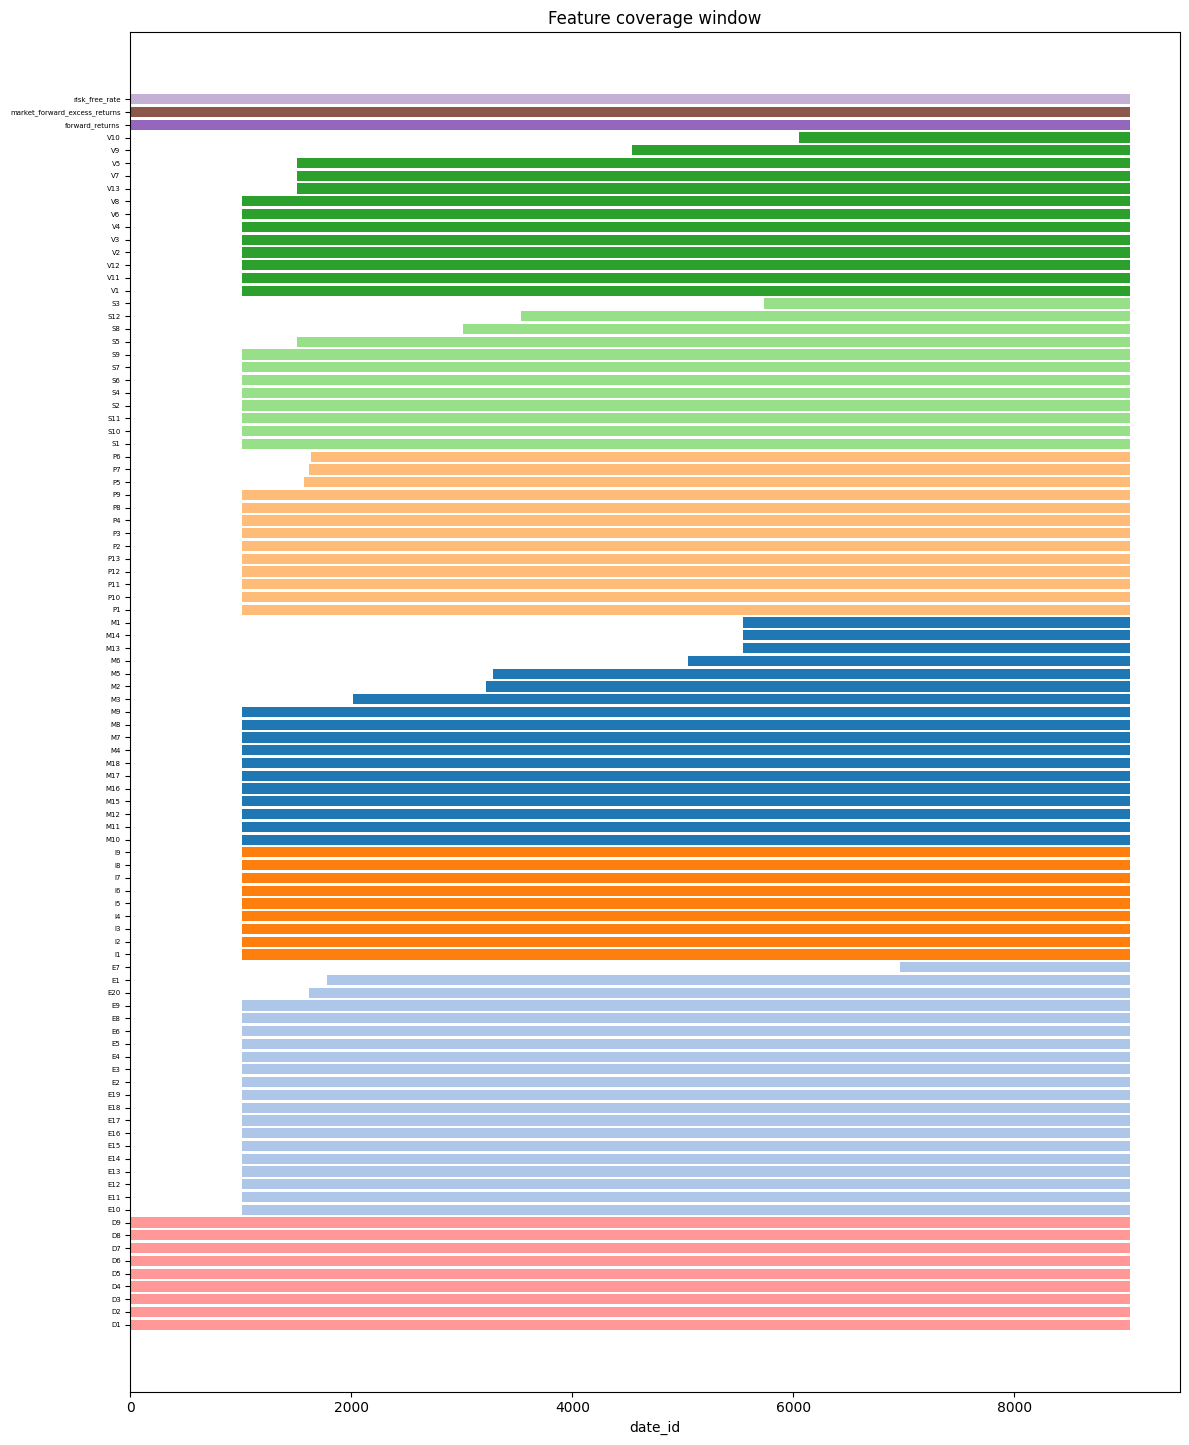

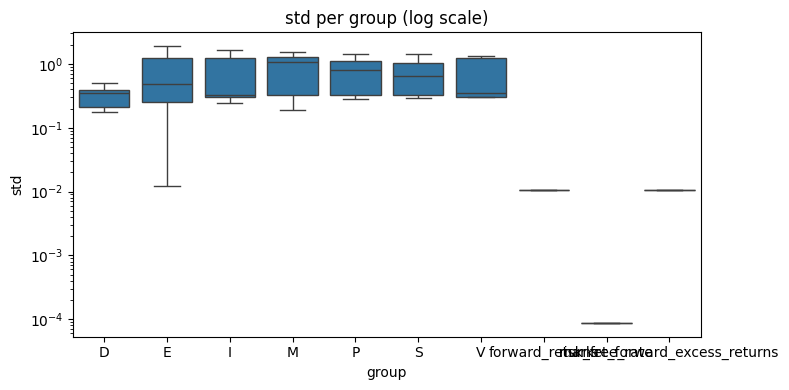

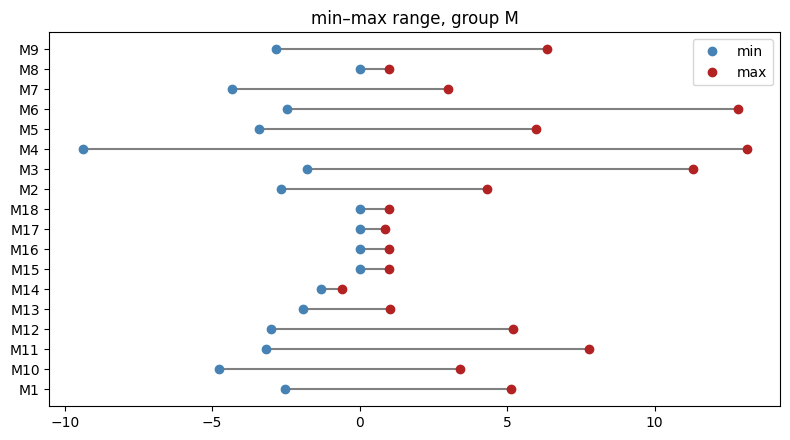

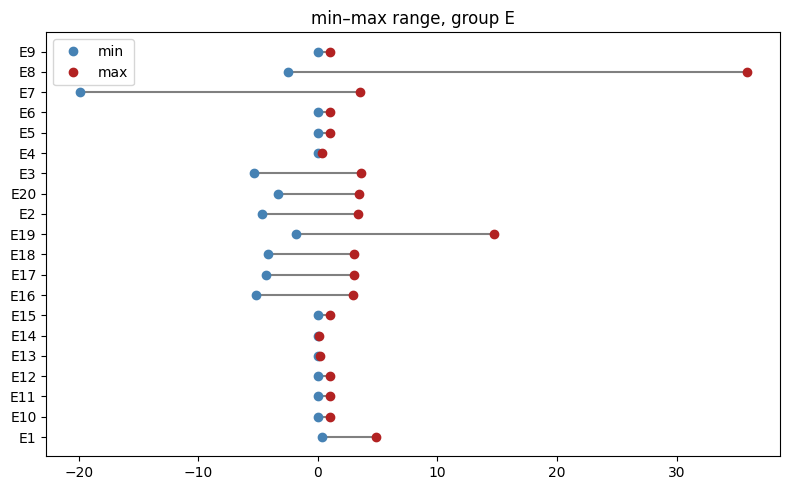

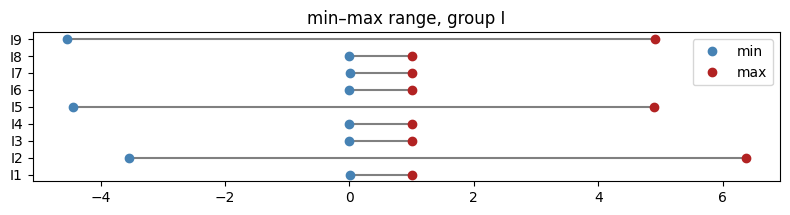

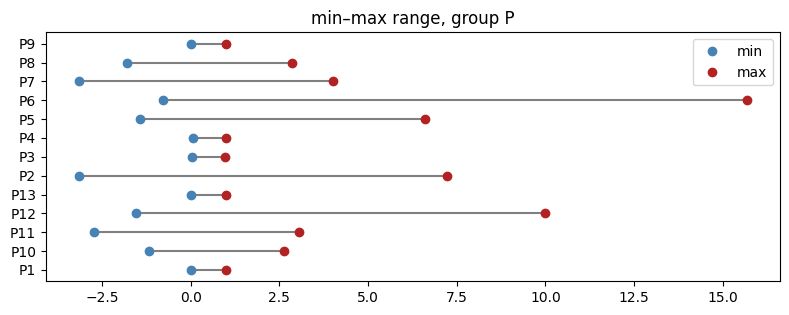

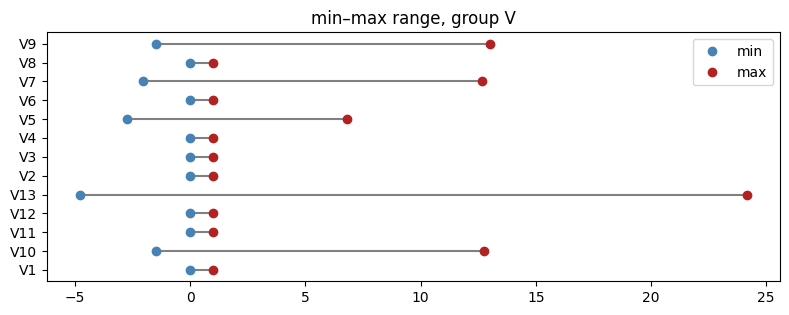

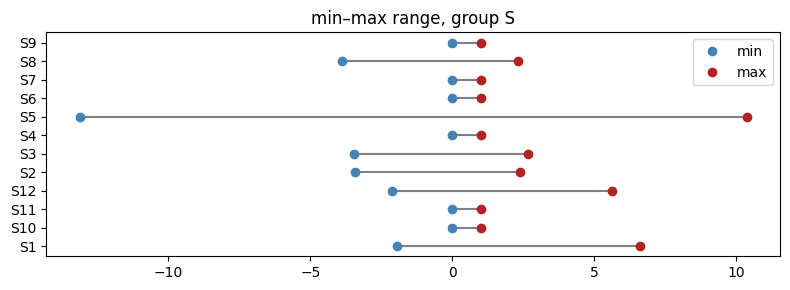

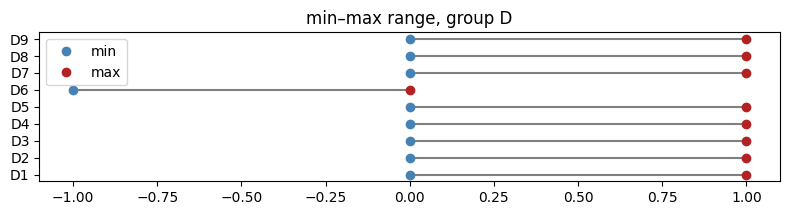

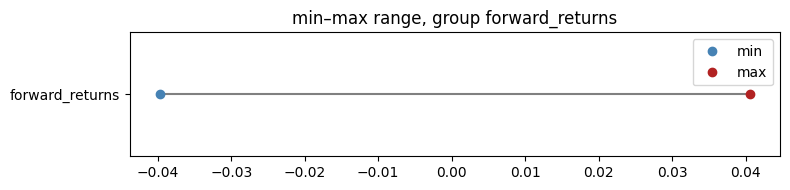

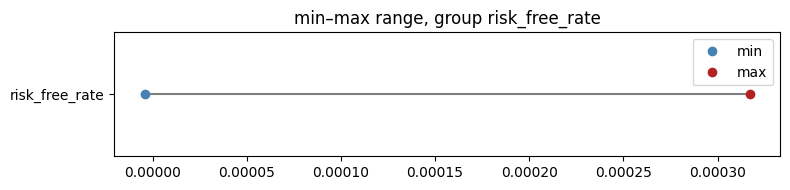

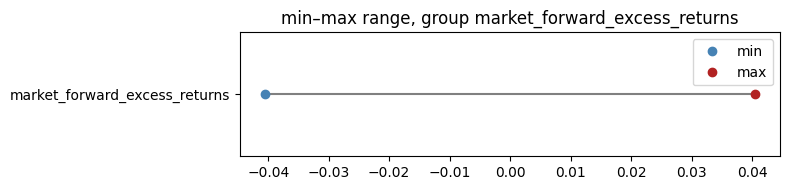

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- dtype counts per group ---
dtype_counts = detail.groupby(["group", "dtype"]).size().unstack(fill_value=0)
dtype_counts.plot(kind="bar", stacked=True, figsize=(8, 4))
plt.ylabel("n_cols")
plt.title("dtype counts per group")
plt.tight_layout()
plt.show()

# --- boxplots: n_missing, pct_missing, n_unique ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=detail, x="group", y="n_missing", ax=axes[0])
sns.boxplot(data=detail, x="group", y="pct_missing", ax=axes[1])
sns.boxplot(data=detail, x="group", y="n_unique", ax=axes[2])
axes[2].set_yscale("log")
for ax, title in zip(axes, ["n_missing", "pct_missing", "n_unique (log)"]):
    ax.set_title(title)
plt.tight_layout()
plt.show()

# --- coverage (first_valid_date -> last_valid_date) as a Gantt chart ---
d = detail.dropna(subset=["first_valid_date", "last_valid_date"]).sort_values(["group", "first_valid_date"])
d = d[d["group"].isin(groups)]
colors = dict(zip(groups, plt.cm.tab20.colors))
fig, ax = plt.subplots(figsize=(12, max(4, 0.15 * len(d))))
for i, row in enumerate(d.itertuples()):
    ax.barh(i, row.last_valid_date - row.first_valid_date, left=row.first_valid_date,
            color=colors[row.group], height=0.8)
ax.set_yticks(range(len(d)))
ax.set_yticklabels(d["column"], fontsize=5)
ax.set_xlabel("date_id")
ax.set_title("Feature coverage window")
plt.tight_layout()
plt.show()

# --- std per group (log scale) ---
plt.figure(figsize=(8, 4))
sns.boxplot(data=detail, x="group", y="std")
plt.yscale("log")
plt.title("std per group (log scale)")
plt.tight_layout()
plt.show()

# --- min-max range per column, faceted by group (dumbbell) ---
for g in groups:
    sub = detail[detail["group"] == g].sort_values("column")
    if sub.empty:
        continue
    plt.figure(figsize=(8, max(2, 0.25 * len(sub))))
    plt.hlines(sub["column"], sub["min"], sub["max"], color="gray")
    plt.plot(sub["min"], sub["column"], "o", color="steelblue", label="min")
    plt.plot(sub["max"], sub["column"], "o", color="firebrick", label="max")
    plt.title(f"min–max range, group {g}")
    plt.legend()
    plt.tight_layout()
    plt.show()

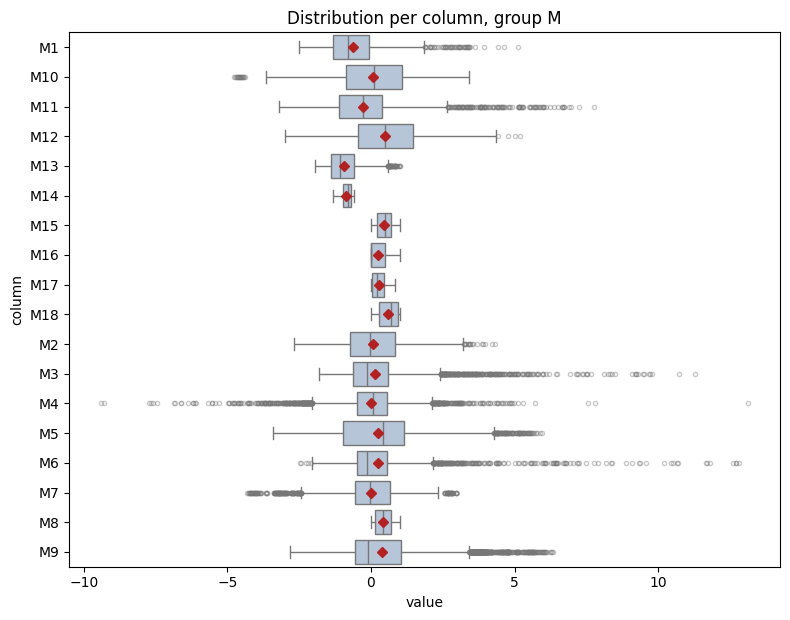

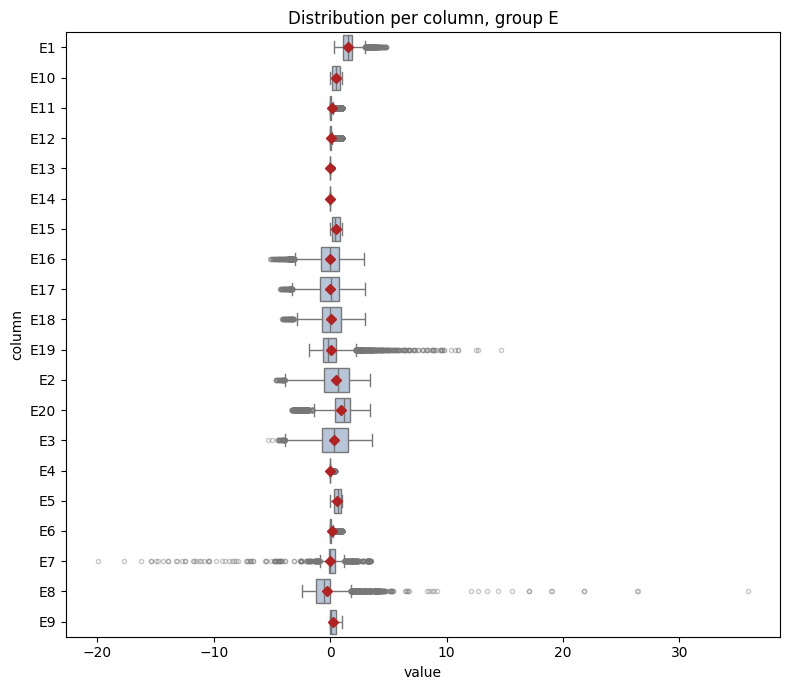

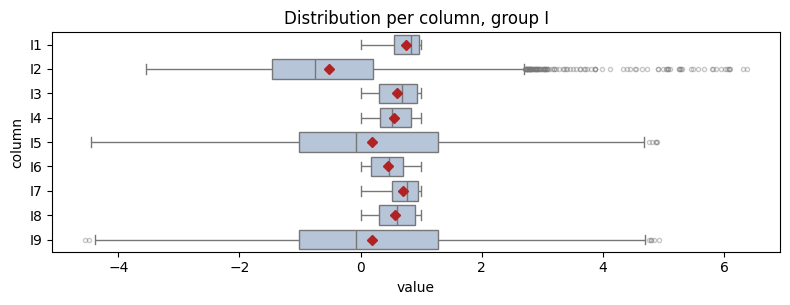

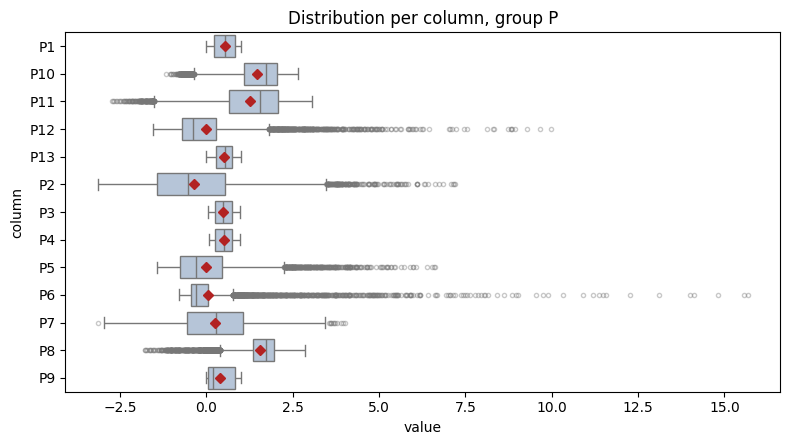

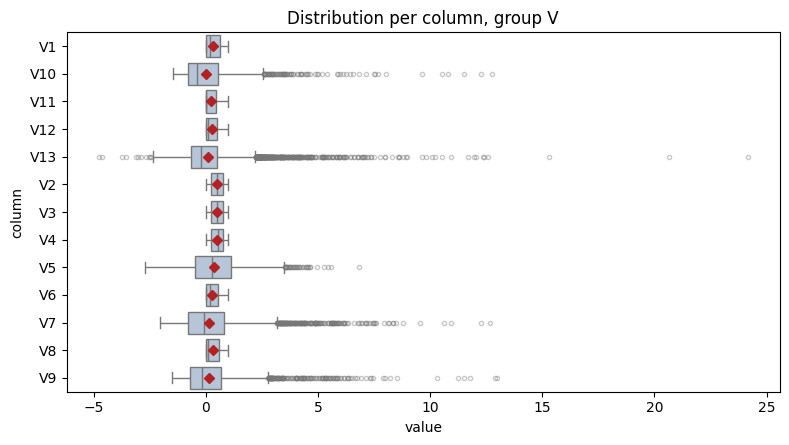

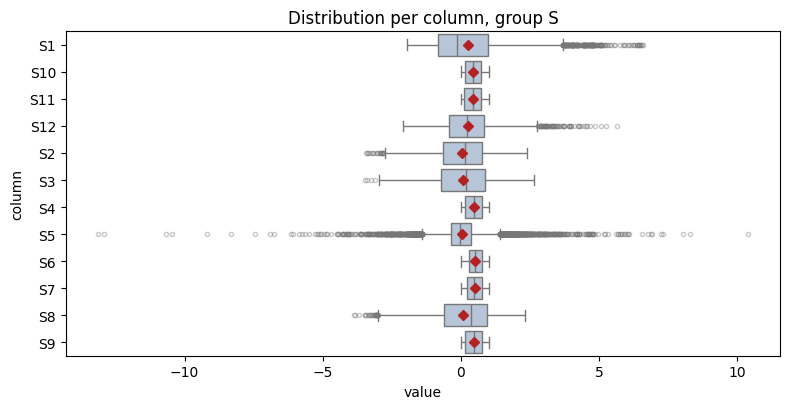

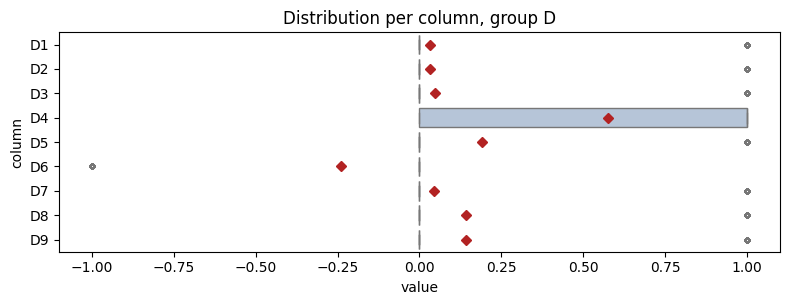

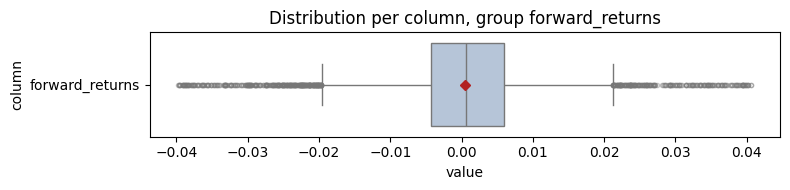

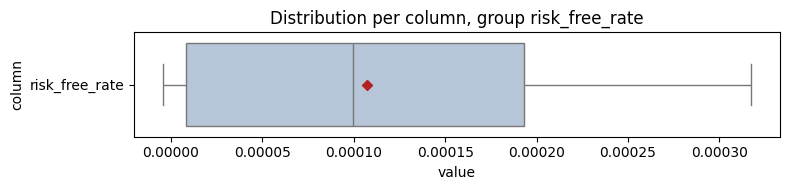

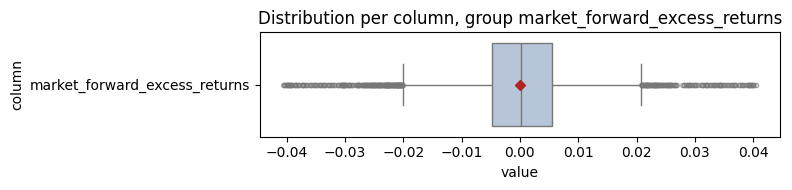

In [8]:
# --- distribution per column, faceted by group (boxplot + mean) ---
for g in groups:
    gcols = group_cols[g]
    if not gcols:
        continue
    long_df = ds_training[gcols].melt(var_name="column", value_name="value").dropna()
    order = sorted(gcols)

    plt.figure(figsize=(8, max(2, 0.35 * len(gcols))))
    sns.boxplot(data=long_df, x="value", y="column", order=order,
                showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "firebrick",
                           "markeredgecolor": "firebrick", "markersize": 5},
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
                color="lightsteelblue")
    plt.title(f"Distribution per column, group {g}")
    plt.tight_layout()
    plt.show()

### Observation: These figures show that there is no common trend in the behavior of the data across variables. That is, some variables have a distribution close to the mean with almost no outliers, while others have a considerable number of outliers. Given the nature of this problem (market prediction), these variables and their associated outliers are significant, and manipulating them in some way might affect the model's predictive ability.

### Idea:
using different windows.

1. Keep the variables as they are, but add a rolling mean, std, skewness, and kurtosis (`feature engineering`) to each existing variable, so the model can also capture trends over time (momentum).
2. Winsorize per rolling window rather than globally, and only for models that need it. Instead of deciding once whether to clip, compute robust z-scores (based on rolling median and MAD rather than mean/std) as an additional feature alongside the raw value. This gives  "how extreme is this reading relative to its recent regime" without discarding the raw magnitude the tree-based model still sees.

### Observation: LightGBM/XGBoost split on rank thresholds, not on raw magnitude, so a handful of extreme values in one column doesn't distort the model the way it would for a linear/distance-based method. Therefore, for these models the above points are not as crucial as for other type of models


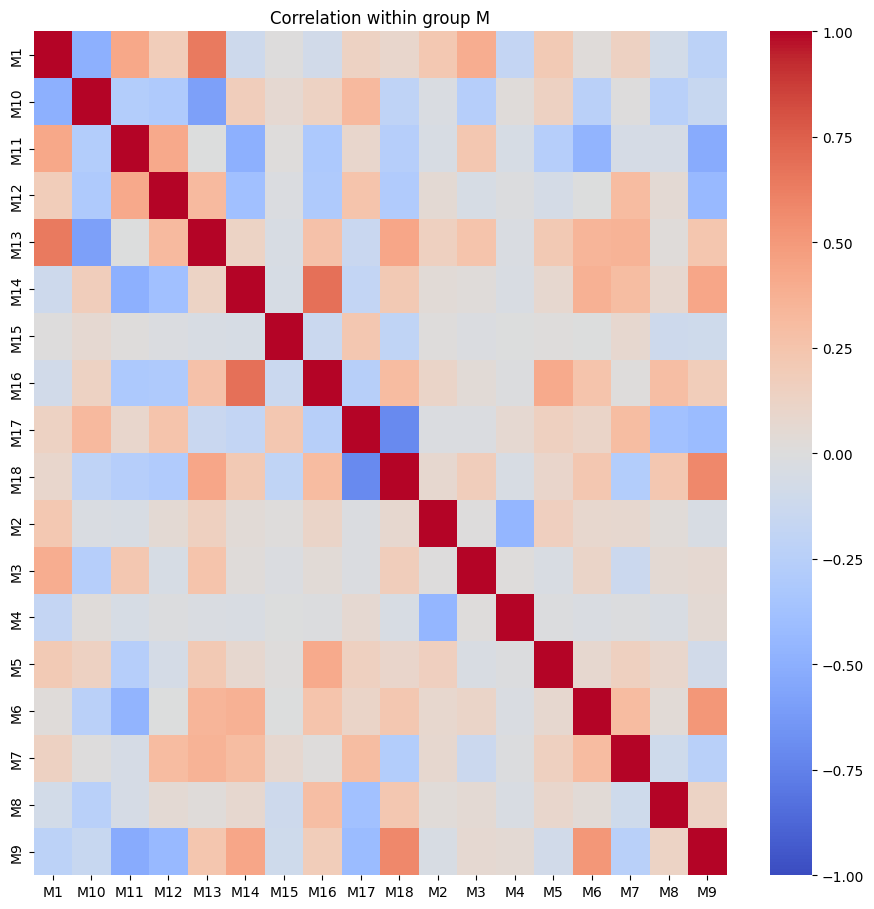

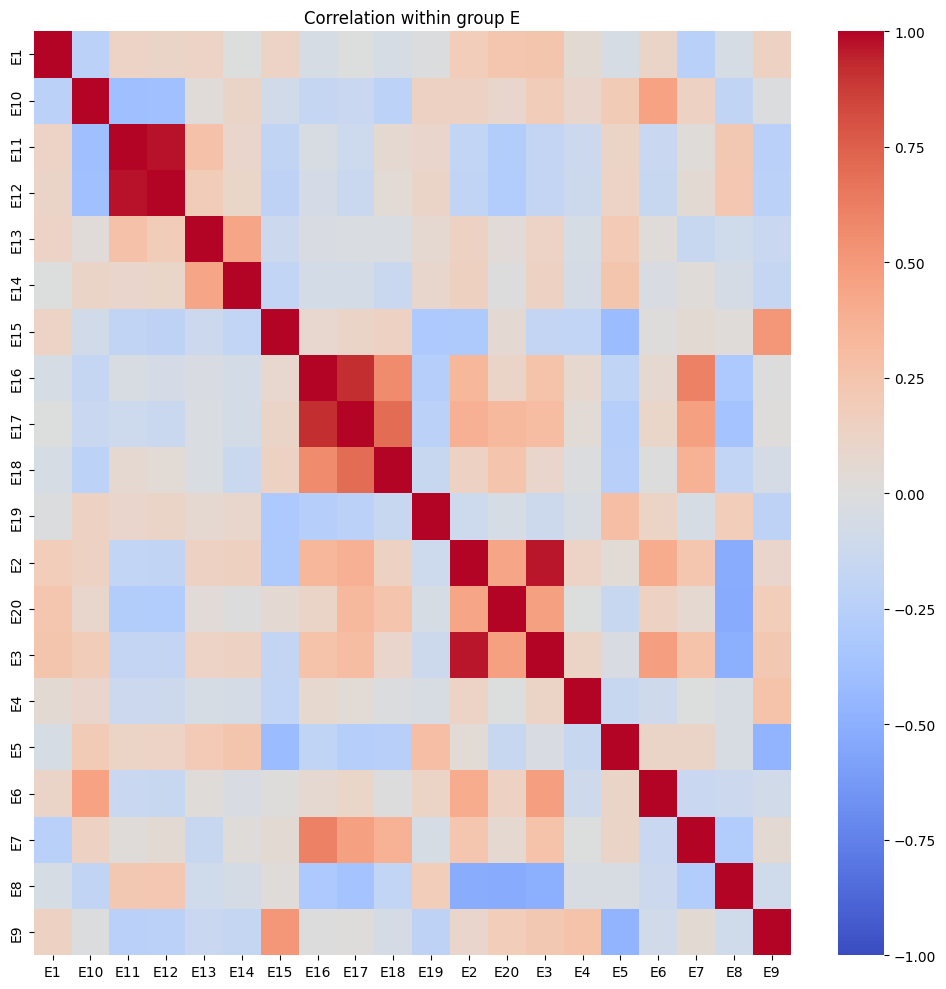

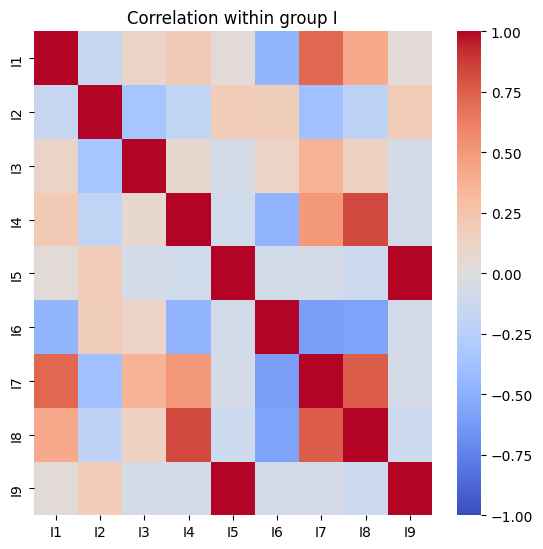

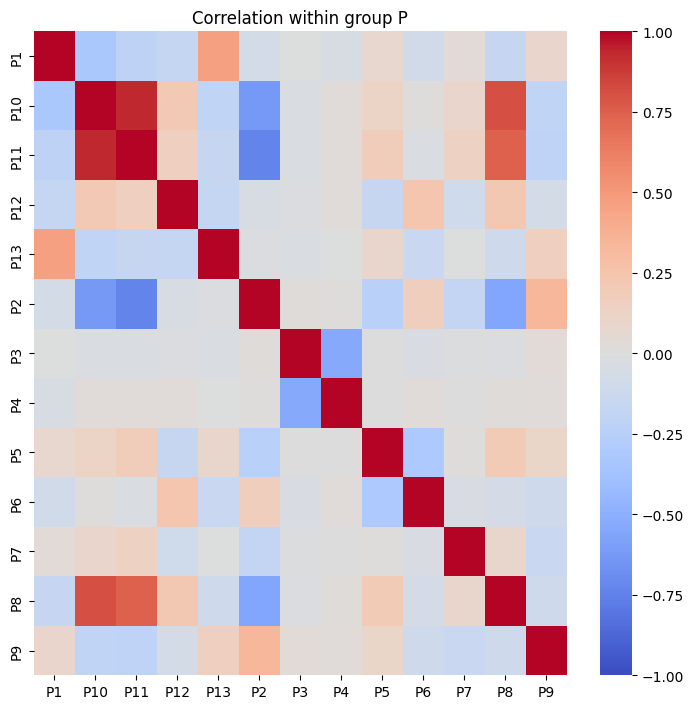

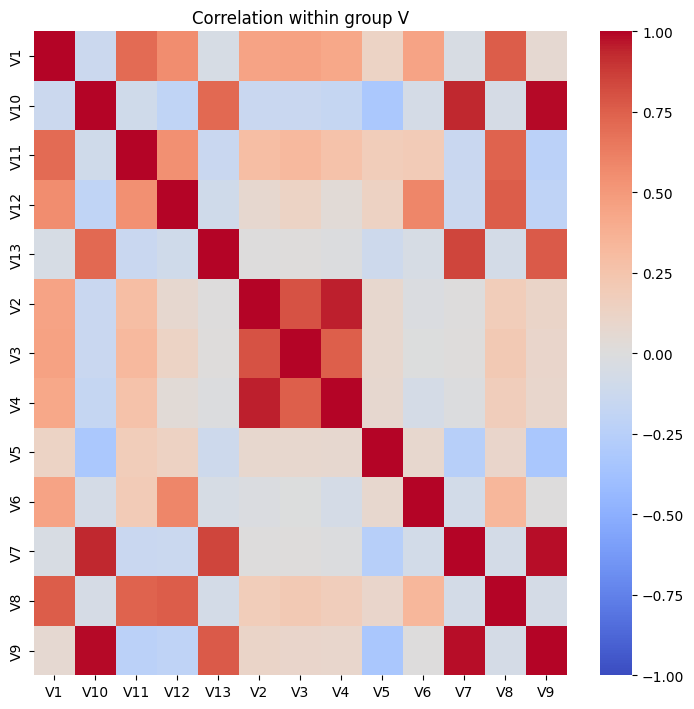

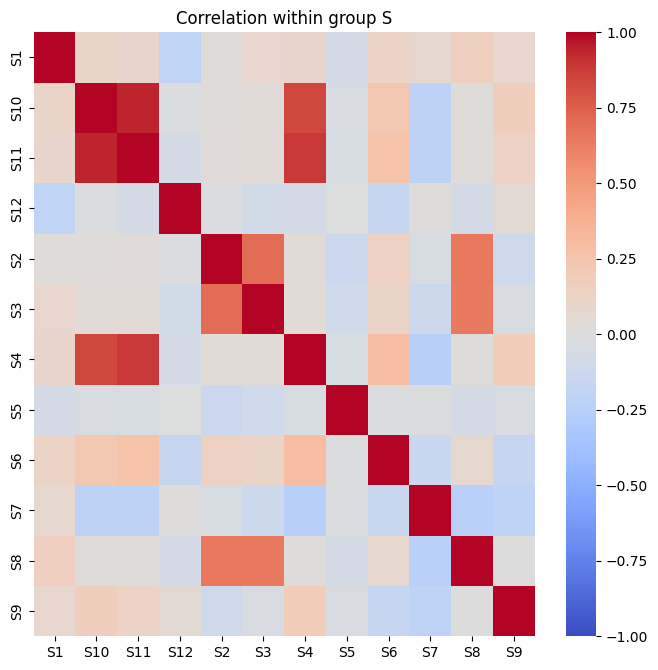

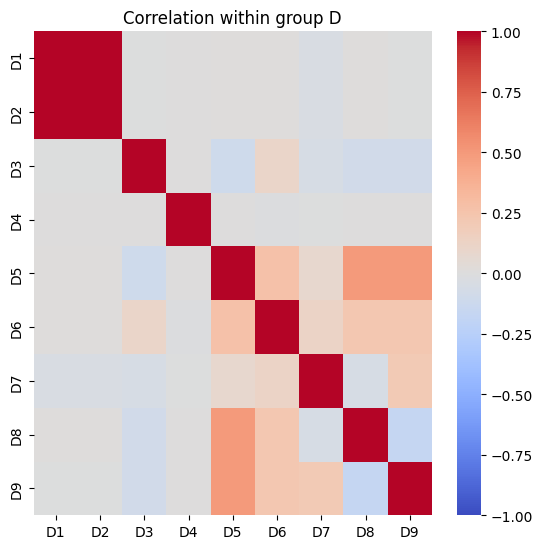

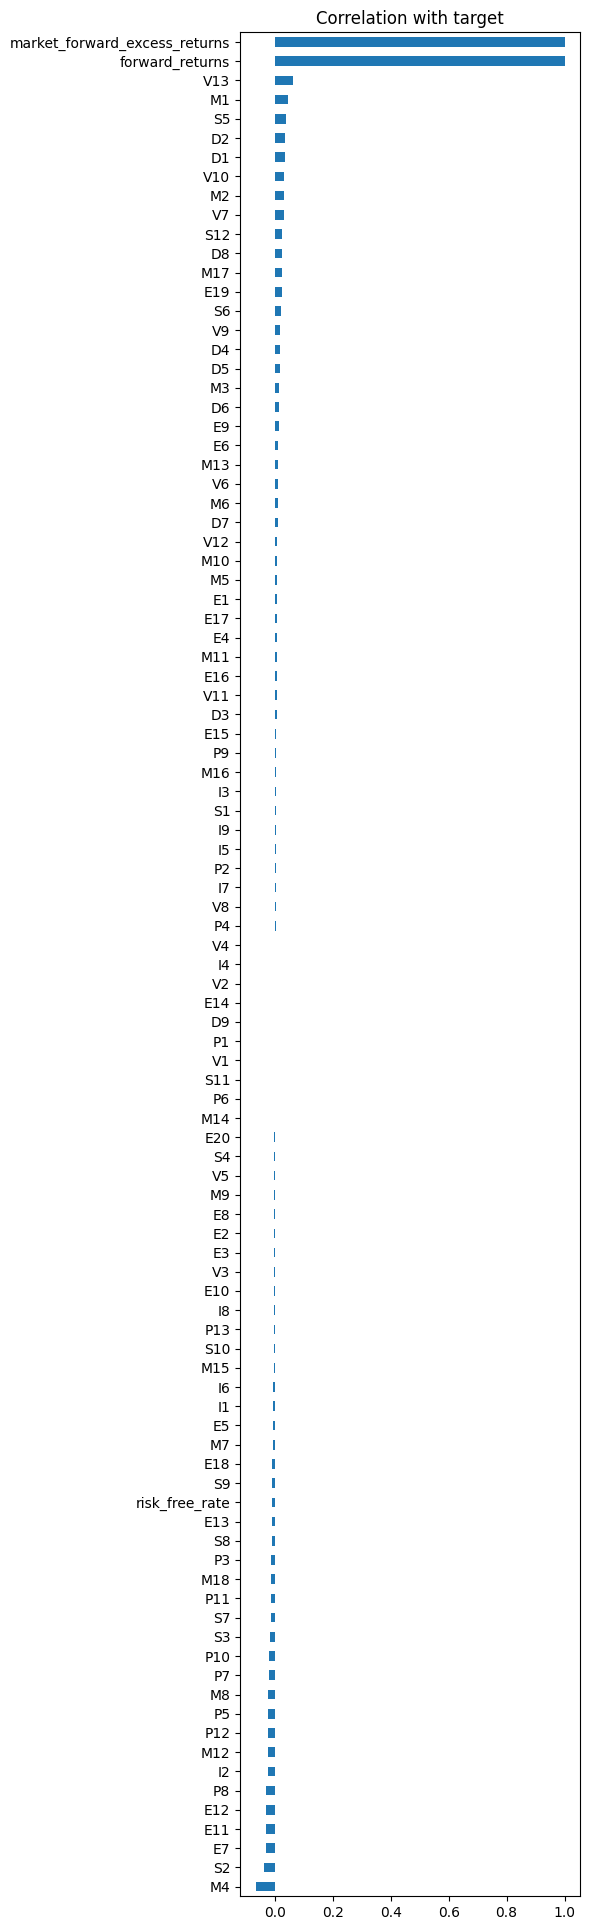

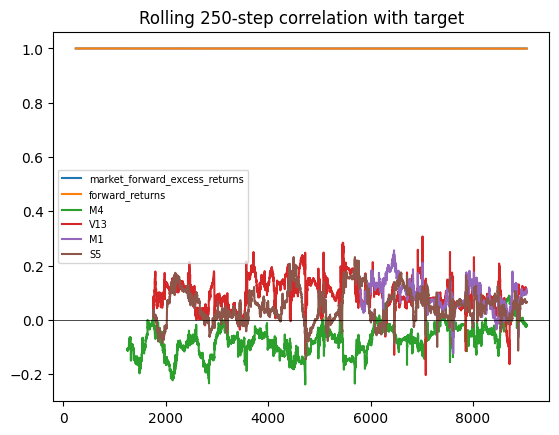

M5                0.051121
E3                0.072021
E6                0.074549
E11               0.082878
P10               0.085468
E10               0.096337
V11               0.098211
E2                0.110702
M16               0.116321
I8                0.132289
I5                0.136852
P11               0.145456
I9                0.147211
risk_free_rate    0.150404
V8                0.170746
I4                0.180118
E5                0.204487
P9                0.205043
M17               0.238290
M14               0.272109
E20               0.277204
M13               0.391501
E12               0.467780
M18               0.593070
E9                0.654068
Name: adf_pvalue, dtype: float64
date_id gaps:
 date_id
1.0    9047
Name: count, dtype: int64
duplicated date_id: 0


In [9]:
from statsmodels.tsa.stattools import adfuller

# --- 1. correlation heatmap within each group ---
for g in groups:
    gcols = group_cols[g]
    if len(gcols) < 2:
        continue
    corr = ds_training[gcols].corr()
    plt.figure(figsize=(0.4*len(gcols)+2, 0.4*len(gcols)+2))
    sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title(f"Correlation within group {g}")
    plt.tight_layout()
    plt.show()

# --- 2. correlation of every feature with the target ---
target = "market_forward_excess_returns"  # adjust to your actual target column
corr_target = ds_training[cols].corrwith(ds_training[target]).sort_values()
corr_target.plot(kind="barh", figsize=(6, 0.2*len(cols)))
plt.title("Correlation with target")
plt.tight_layout()
plt.show()

# --- 2b. rolling correlation with target, to check regime stability ---
window = 250  # ~1 trading year
top_feats = corr_target.abs().sort_values(ascending=False).head(6).index
for c in top_feats:
    roll_corr = ds_training[c].rolling(window).corr(ds_training[target])
    plt.plot(ds_training["date_id"], roll_corr, label=c)
plt.axhline(0, color="black", lw=0.5)
plt.legend(fontsize=7)
plt.title(f"Rolling {window}-step correlation with target")
plt.show()

# --- 3. stationarity check (ADF test) per column ---
adf_results = {}
for c in cols:
    series = ds_training[c].dropna()
    if len(series) > 30:
        adf_results[c] = adfuller(series)[1]  # p-value
adf_df = pd.Series(adf_results, name="adf_pvalue").sort_values()
print(adf_df[adf_df > 0.05])  # p > 0.05 -> likely non-stationary

# --- 4. date_id continuity ---
diffs = ds_training["date_id"].diff().dropna()
print("date_id gaps:\n", diffs.value_counts())
print("duplicated date_id:", ds_training["date_id"].duplicated().sum())

In [10]:
# --- 6. constant / near-duplicate columns ---
nunique = ds_training[cols].nunique()
print("constant columns:", nunique[nunique <= 1].index.tolist())

dup_groups = ds_training[cols].T.duplicated(keep=False)
print("duplicate columns:", dup_groups[dup_groups].index.tolist())

# --- 7. missingness as a signal: does target differ when a feature is NaN? ---
for c in cols:
    if ds_training[c].isna().sum() == 0:
        continue
    mean_present = ds_training.loc[ds_training[c].notna(), target].mean()
    mean_missing = ds_training.loc[ds_training[c].isna(), target].mean()
    if abs(mean_present - mean_missing) > 1e-6:
        print(f"{c}: target mean present={mean_present:.4f} vs missing={mean_missing:.4f}")

constant columns: []
duplicate columns: ['D1', 'D2']
E1: target mean present=0.0000 vs missing=0.0001
E10: target mean present=0.0001 vs missing=-0.0001
E11: target mean present=0.0001 vs missing=-0.0001
E12: target mean present=0.0001 vs missing=-0.0001
E13: target mean present=0.0001 vs missing=-0.0001
E14: target mean present=0.0001 vs missing=-0.0001
E15: target mean present=0.0001 vs missing=-0.0001
E16: target mean present=0.0001 vs missing=-0.0001
E17: target mean present=0.0001 vs missing=-0.0001
E18: target mean present=0.0001 vs missing=-0.0001
E19: target mean present=0.0001 vs missing=-0.0001
E2: target mean present=0.0001 vs missing=-0.0001
E20: target mean present=0.0001 vs missing=0.0000
E3: target mean present=0.0001 vs missing=-0.0001
E4: target mean present=0.0001 vs missing=-0.0001
E5: target mean present=0.0001 vs missing=-0.0001
E6: target mean present=0.0001 vs missing=-0.0001
E7: target mean present=0.0002 vs missing=0.0000
E8: target mean present=0.0001 vs missi

# Test dataset

### An important note from the official documentation: "The test set used for the public leaderboard set is a copy of the last 180 date IDs in the train set."
### with this information in mind, I will extent the test dataset to a larger proportion of the train dataset

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd


In [13]:
data_path = Path("/kaggle/input/competitions/hull-tactical-market-prediction")
test_path = Path("test.csv")
ds_test = pd.read_csv(data_path/test_path)
ds_test.head()

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V4,V5,V6,V7,V8,V9,is_scored,lagged_forward_returns,lagged_risk_free_rate,lagged_market_forward_excess_returns
0,8980,0,0,0,0,1,0,0,1,0,...,0.828042,0.999173,0.759921,-0.803127,0.170966,-0.751909,True,0.003541,0.000161,0.003068
1,8981,0,0,0,0,1,0,0,1,0,...,0.831349,1.120336,0.556217,-0.686192,0.141865,-0.660326,True,-0.005964,0.000162,-0.006437
2,8982,0,0,0,0,1,0,0,0,1,...,0.832672,1.088992,0.665344,-0.459367,0.199405,-0.510979,True,-0.007410,0.000160,-0.007882
3,8983,0,0,0,0,1,0,0,0,1,...,0.835979,1.040988,0.594577,-0.561643,0.161706,-0.575997,True,0.005420,0.000160,0.004949
4,8984,0,0,0,0,0,0,1,0,1,...,0.839947,0.944593,0.715608,-0.692649,0.124669,-0.654045,True,0.008357,0.000159,0.007887


In [16]:
print(f"Total number of time steps (rows) in test dataset: {len(ds_test)}")
if len(ds_test) != 180:
    print(f"Number of time steps is different to what official documentation says")

Total number of time steps (rows) in test dataset: 10
Number of time steps is different to what official documentation says


In [30]:
#this is the training dataset with the same date id as the test dataset
ds_train_matched_test = ds_training[ds_training["date_id"].isin(ds_test["date_id"].values)]
ds_train_matched_test

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
8980,8980,0,0,0,0,1,0,0,1,0,...,0.892196,0.828042,0.999173,0.759921,-0.803127,0.170966,-0.751909,-0.005964,0.000162,-0.006437
8981,8981,0,0,0,0,1,0,0,1,0,...,0.699074,0.831349,1.120336,0.556217,-0.686192,0.141865,-0.660326,-0.007410,0.000160,-0.007882
8982,8982,0,0,0,0,1,0,0,0,1,...,0.647487,0.832672,1.088992,0.665344,-0.459367,0.199405,-0.510979,0.005420,0.000160,0.004949
8983,8983,0,0,0,0,1,0,0,0,1,...,0.445767,0.835979,1.040988,0.594577,-0.561643,0.161706,-0.575997,0.008357,0.000159,0.007887
8984,8984,0,0,0,0,0,0,1,0,1,...,0.707672,0.839947,0.944593,0.715608,-0.692649,0.124669,-0.654045,-0.002896,0.000159,-0.003365
8985,8985,0,0,0,0,0,0,0,0,0,...,0.469577,0.837963,1.226772,0.822751,-0.707361,0.142857,-0.649616,0.002457,0.000155,0.001990
8986,8986,0,0,0,0,0,0,0,0,0,...,0.671958,0.837963,0.785877,0.805556,-0.715692,0.196098,-0.668289,0.002312,0.000156,0.001845
8987,8987,0,0,1,0,0,0,0,0,0,...,0.481481,0.787698,0.834898,0.823413,-0.723949,0.133929,-0.670946,0.002891,0.000156,0.002424
8988,8988,0,0,0,0,0,0,0,0,0,...,0.655423,0.783730,0.994026,0.851852,-0.684937,0.101852,-0.646265,0.008310,0.000156,0.007843
8989,8989,0,0,0,0,0,0,0,0,0,...,0.066799,0.783730,1.068037,0.879630,-0.764806,0.079034,-0.705662,0.000099,0.000156,-0.000368


In [37]:
# align both on date_id so rows correspond correctly
subset_train_aligned = ds_train_matched_test.set_index("date_id").sort_index()
test_aligned = ds_test.set_index("date_id").sort_index()

# sanity check: same columns and same date_ids on both sides
common_cols = subset_train_aligned.columns.intersection(test_aligned.columns)
print("columns on BOTG:", common_cols)
print("columns only in train:", set(subset_train_aligned.columns) - set(test_aligned.columns))
print("columns only in test:", set(test_aligned.columns) - set(subset_train_aligned.columns))
print("date_ids only in train:", set(subset_train_aligned.index) - set(test_aligned.index))
print("date_ids only in test:", set(test_aligned.index) - set(subset_train_aligned.index))

a, b = subset_train_aligned[common_cols], test_aligned[common_cols]

# element-wise diff (treats NaN==NaN as equal)
diff_mask = ~((a == b) | (a.isna() & b.isna()))

# rows that have at least one difference
rows_with_diff = diff_mask.any(axis=1)
print("n rows with at least one different value (accros columns):", rows_with_diff.sum())

# columns that have at least one difference
cols_with_diff = diff_mask.any(axis=0)
print("columns with at least one differences (accros rows):\n", cols_with_diff.sum())

# long-format table: exactly which (date_id, column) differ, with both values
diffs_long = diff_mask.stack()
diffs_long = diffs_long[diffs_long].index.to_frame(index=False)
diffs_long.columns = ["date_id", "column"]
diffs_long["train_value"] = [a.loc[r, c] for r, c in zip(diffs_long["date_id"], diffs_long["column"])]
diffs_long["test_value"] = [b.loc[r, c] for r, c in zip(diffs_long["date_id"], diffs_long["column"])]
diffs_long

columns on BOTG: Index(['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'E1', 'E10',
       'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E2',
       'E20', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'I1', 'I2', 'I3', 'I4',
       'I5', 'I6', 'I7', 'I8', 'I9', 'M1', 'M10', 'M11', 'M12', 'M13', 'M14',
       'M15', 'M16', 'M17', 'M18', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8',
       'M9', 'P1', 'P10', 'P11', 'P12', 'P13', 'P2', 'P3', 'P4', 'P5', 'P6',
       'P7', 'P8', 'P9', 'S1', 'S10', 'S11', 'S12', 'S2', 'S3', 'S4', 'S5',
       'S6', 'S7', 'S8', 'S9', 'V1', 'V10', 'V11', 'V12', 'V13', 'V2', 'V3',
       'V4', 'V5', 'V6', 'V7', 'V8', 'V9'],
      dtype='object')
columns only in train: {'risk_free_rate', 'market_forward_excess_returns', 'forward_returns'}
columns only in test: {'lagged_forward_returns', 'is_scored', 'lagged_risk_free_rate', 'lagged_market_forward_excess_returns'}
date_ids only in train: set()
date_ids only in test: set()
n rows with at least o

,date_id,column,train_value,test_value


### this tells me that both, the subset of training and test datasets, are identical. However, the names between train and test for some columns change. These are:
* risk_free_rate -> lagged_risk_free_rate
* market_forward_excess_returns -> lagged_market_forward_excess_returns
* forward_returns -> lagged_forward_returns

### Observation: these features in the test set correspond to the features in the train set at t + 1. In other words the data for the lagged data at `t`correspond to the data at `t-1`for the other columns in the test set

In [38]:
pairs = [
    ("risk_free_rate", "lagged_risk_free_rate"),
    ("market_forward_excess_returns", "lagged_market_forward_excess_returns"),
    ("forward_returns", "lagged_forward_returns"),
]

subset_train_aligned = ds_train_matched_test.set_index("date_id").sort_index()
test_aligned = ds_test.set_index("date_id").sort_index()

all_ok = True
mismatch_rows = []

for source_col, lagged_col in pairs:
    # shift train's source column forward by 1 date_id position before comparing
    expected = subset_train_aligned[source_col].shift(1)
    expected.index = subset_train_aligned.index  # keep aligned to date_id
    actual = test_aligned[lagged_col]

    # treat NaN == NaN as a match
    mismatch = ~((expected == actual) | (expected.isna() & actual.isna()))

    if mismatch.any():
        all_ok = False
        sub = pd.DataFrame({
            "date_id": expected.index[mismatch],
            "column": lagged_col,
            "train_value": expected[mismatch].values,
            "test_value": actual[mismatch].values,
        })
        sub["diff"] = sub["train_value"] - sub["test_value"]
        mismatch_rows.append(sub)

if all_ok:
    print("* risk_free_rate -> lagged_risk_free_rate\n"
          "* market_forward_excess_returns -> lagged_market_forward_excess_returns\n"
          "* forward_returns -> lagged_forward_returns, for all tested rows")
else:
    mismatches_df = pd.concat(mismatch_rows, ignore_index=True)
    print(mismatches_df)

   date_id                                column  train_value  test_value  \
0     8980                 lagged_risk_free_rate          NaN    0.000161   
1     8980  lagged_market_forward_excess_returns          NaN    0.003068   
2     8980                lagged_forward_returns          NaN    0.003541   

   diff  
0   NaN  
1   NaN  
2   NaN  


### The NaN values in `train`is because when the data was generated, there were no values at t+1, but when the test set was generated, this data existed, check that the train set extends further than the dates in the test set

# Checking the percentage of the test set relative to the train set

In [46]:
train_length = len(ds_training)
subset_train_length = len(ds_train_matched_test)
print(f"Percentage of data in the test set that is in the training set:" \
f"{(subset_train_length/train_length)*100}")
print(f"Percentage of the sub training set that is in the test set: {(subset_train_length/len(ds_test))*100}")

Percentage of data in the test set that is in the training set:0.11052166224580018
Percentage of the sub training set that is in the test set: 100.0


According to this, the test set contains less than 1% of the data used for training

# Making train/test/val set
Now, I will split the train set into 80%/10%/10% for the trianing, validation and test. When doing this, I will take that all features contain valid values in the training set, as we have seen some of them start to have values later in the dataset. Additionally, the test and validation dataset are created as it is the `test.csv`with the lagged features, i.e. lagged features are t+1 that the other columns. This proportion is selected because there are some features that only appear after the 70% of the total time series

In [112]:
import pandas as pd
import numpy as np

RAW_TARGET_COLS = ["risk_free_rate", "market_forward_excess_returns", "forward_returns"]
LAG_MAP = {
    "risk_free_rate": "lagged_risk_free_rate",
    "market_forward_excess_returns": "lagged_market_forward_excess_returns",
    "forward_returns": "lagged_forward_returns",
}

df = ds_training.sort_values("date_id").reset_index(drop=True)
feature_cols = [c for c in df.columns if c not in RAW_TARGET_COLS + ["date_id"]]

# --- 1. find the first date_id where ALL feature columns have valid data ---
first_valid_per_col = df[feature_cols].apply(lambda s: s.first_valid_index())
cutoff_idx = first_valid_per_col.max()
cutoff_date = df.loc[cutoff_idx, "date_id"]
print(f"date_id >= {cutoff_date} so all features are populated")

df_clean = df  # [df["date_id"] >= cutoff_date].reset_index(drop=True)
# assert df_clean[feature_cols].isna().sum().sum() == 0, "features still have gaps after cropping"

# --- 2. chronological split (no shuffling -> no leakage across time) ---
n = len(df_clean)
n_train = int(n * 0.80)
n_val = int(n * 0.10)
# remainder goes to test, so rounding doesn't drop rows

train_df = df_clean.iloc[:n_train].copy()
val_df = df_clean.iloc[n_train:n_train + n_val].copy()
test_df = df_clean.iloc[n_train + n_val:].copy()

print(f"train: {train_df['date_id'].min()}–{train_df['date_id'].max()} ({len(train_df)} rows)")
print(f"val:   {val_df['date_id'].min()}–{val_df['date_id'].max()} ({len(val_df)} rows)")
print(f"test:  {test_df['date_id'].min()}–{test_df['date_id'].max()} ({len(test_df)} rows)")

assert set(train_df["date_id"]) & set(val_df["date_id"]) == set()
assert set(val_df["date_id"]) & set(test_df["date_id"]) == set()
assert set(train_df["date_id"]) & set(test_df["date_id"]) == set()


# --- 3. rebuild val/test to look like test.csv: raw target cols -> lagged_* cols ---
def to_test_like(split_df, full_df, raw_target_cols, lag_map):
    """
    Returns a single dataframe matching test.csv's shape:
    original features + date_id, raw target cols dropped, lagged_* cols added.
    Lag is computed against the full chronological series (past rows only -> no leakage).
    """
    lagged_full = full_df[["date_id"] + raw_target_cols].copy()
    for raw_col, lag_col in lag_map.items():
        lagged_full[lag_col] = lagged_full[raw_col].shift(1)  # t-1, past only

    lagged_split = lagged_full[lagged_full["date_id"].isin(split_df["date_id"])][
        ["date_id"] + list(lag_map.values())
    ]

    out = split_df.drop(columns=raw_target_cols).merge(lagged_split, on="date_id", how="left")
    return out


# train: kept as-is, with the real (unlagged) target columns
train_out = train_df.copy()

# val/test: test.csv-shaped, raw targets replaced by lagged_*
val_out = to_test_like(val_df, df_clean, RAW_TARGET_COLS, LAG_MAP)
test_out = to_test_like(test_df, df_clean, RAW_TARGET_COLS, LAG_MAP)

print("\ntrain columns:", train_out.columns.tolist())
print("\nval columns:  ", val_out.columns.tolist())
print("\ntest columns: ", test_out.columns.tolist())

date_id >= 6969 so all features are populated
train: 0–7237 (7238 rows)
val:   7238–8141 (904 rows)
test:  8142–9047 (906 rows)

train columns: ['date_id', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E2', 'E20', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'M1', 'M10', 'M11', 'M12', 'M13', 'M14', 'M15', 'M16', 'M17', 'M18', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'P1', 'P10', 'P11', 'P12', 'P13', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'S1', 'S10', 'S11', 'S12', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'V1', 'V10', 'V11', 'V12', 'V13', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'forward_returns', 'risk_free_rate', 'market_forward_excess_returns']

val columns:   ['date_id', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E2', 'E20', 'E3', 'E

# Cheking the data is correctly constructed

In [113]:
import pandas as pd
import numpy as np

def check_lag_relationship(split_out, split_name, df_clean, lag_map):
    """
    Test 1: verifies that lagged_col[t] in the split == raw_col[t-1] in the
    original chronological training data (i.e. a value born at date t in
    df_clean correctly surfaces as the lag at date t+1 in val/test).
    """
    print(f"--- Test 1 [{split_name}]: lag(t+1) relationship holds against df_clean ---")
    full_indexed = df_clean.set_index("date_id").sort_index()
    split_indexed = split_out.set_index("date_id").sort_index()

    ok = True
    for raw_col, lag_col in lag_map.items():
        if lag_col not in split_out.columns:
            ok = False
            print(f"FAIL: {lag_col} not found in {split_name}_out")
            continue

        expected = full_indexed[raw_col].shift(1)  # raw_col[t-1]
        actual = split_indexed[lag_col]
        expected_aligned, actual_aligned = expected.align(actual, join="inner")

        mismatch = ~((expected_aligned == actual_aligned) |
                     (expected_aligned.isna() & actual_aligned.isna()))
        n_bad = mismatch.sum()
        if n_bad > 0:
            ok = False
            print(f"FAIL: {lag_col} != {raw_col}[t-1] for {n_bad} rows "
                  f"(date_ids: {expected_aligned.index[mismatch].tolist()[:10]}{'...' if n_bad > 10 else ''})")
        else:
            print(f"OK: {lag_col} == {raw_col}[t-1] for all {len(expected_aligned)} rows")

    if ok:
        print(f"SUCCESSFUL — Test 1 [{split_name}]: every lagged_* column matches the source "
              f"column shifted by one date_id, confirming the lag was built against the correct "
              f"prior-day value with no shift errors.\n")
    else:
        print(f"FAILED — Test 1 [{split_name}]\n")
    return ok


def check_no_overlap(train_df, val_df, test_df):
    """
    Test 2: verifies train/val/test share no date_id, i.e. no row appears in
    more than one split.
    """
    print("--- Test 2: no date_id overlap between splits ---")
    tv = set(train_df["date_id"]) & set(val_df["date_id"])
    vt = set(val_df["date_id"]) & set(test_df["date_id"])
    tt = set(train_df["date_id"]) & set(test_df["date_id"])

    ok = not (tv or vt or tt)
    if not ok:
        if tv: print(f"FAIL: train/val overlap on date_ids: {sorted(tv)[:10]}")
        if vt: print(f"FAIL: val/test overlap on date_ids: {sorted(vt)[:10]}")
        if tt: print(f"FAIL: train/test overlap on date_ids: {sorted(tt)[:10]}")
        print("FAILED — Test 2\n")
    else:
        print("SUCCESSFUL — Test 2: train, val and test share no date_id; the three splits "
              "are strictly disjoint in time.\n")
    return ok


def check_boundary_wall(train_out, val_out, test_out, gap=1):
    """
    Test 3: verifies there is at least `gap` date_id(s) of separation between
    splits, so that no lagged_* value in val/test was computed from a raw
    value sitting in the immediately preceding split (which would let
    information cross the split boundary).
    """
    print("--- Test 3: 1-step buffer between splits (no cross-boundary leakage) ---")
    ok = True

    train_max = train_out["date_id"].max()
    val_min = val_out["date_id"].min()
    val_max = val_out["date_id"].max()
    test_min = test_out["date_id"].min()

    train_val_gap = val_min - train_max
    val_test_gap = test_min - val_max

    if train_val_gap <= gap:
        ok = False
        print(f"FAIL: train ends at date_id={train_max}, val starts at date_id={val_min} "
              f"(gap={train_val_gap}). val's first row's lagged_* value was computed from "
              f"train's last row — information crosses the boundary.")
    else:
        print(f"OK: train ends at {train_max}, val starts at {val_min} (gap={train_val_gap})")

    if val_test_gap <= gap:
        ok = False
        print(f"FAIL: val ends at date_id={val_max}, test starts at date_id={test_min} "
              f"(gap={val_test_gap}). test's first row's lagged_* value was computed from "
              f"val's last row — information crosses the boundary.")
    else:
        print(f"OK: val ends at {val_max}, test starts at {test_min} (gap={val_test_gap})")

    if ok:
        print(f"SUCCESSFUL — Test 3: there is at least a {gap}-step buffer at every split "
              f"boundary, so no lagged_* value in val/test was built from a raw value "
              f"belonging to the previous split.\n")
    else:
        print("FAILED — Test 3: no buffer currently exists between splits. Fix: drop the "
              "first row of val_out and test_out (their lagged_* columns depend on the "
              "previous split's last raw value), e.g.:\n"
              "  val_out = val_out[val_out['date_id'] > train_out['date_id'].max() + 1]\n"
              "  test_out = test_out[test_out['date_id'] > val_out['date_id'].max() + 1]\n")
    return ok


# --- run all checks ---
r1_val = check_lag_relationship(val_out, "val", df_clean, LAG_MAP)
r1_test = check_lag_relationship(test_out, "test", df_clean, LAG_MAP)
r2 = check_no_overlap(train_out, val_out, test_out)
r3 = check_boundary_wall(train_out, val_out, test_out, gap=1)

if all([r1_val, r1_test, r2, r3]):
    print("ALL TESTS SUCCESSFUL")
else:
    print("ONE OR MORE TESTS FAILED — see details above")

--- Test 1 [val]: lag(t+1) relationship holds against df_clean ---
OK: lagged_risk_free_rate == risk_free_rate[t-1] for all 904 rows
OK: lagged_market_forward_excess_returns == market_forward_excess_returns[t-1] for all 904 rows
OK: lagged_forward_returns == forward_returns[t-1] for all 904 rows
SUCCESSFUL — Test 1 [val]: every lagged_* column matches the source column shifted by one date_id, confirming the lag was built against the correct prior-day value with no shift errors.

--- Test 1 [test]: lag(t+1) relationship holds against df_clean ---
OK: lagged_risk_free_rate == risk_free_rate[t-1] for all 906 rows
OK: lagged_market_forward_excess_returns == market_forward_excess_returns[t-1] for all 906 rows
OK: lagged_forward_returns == forward_returns[t-1] for all 906 rows
SUCCESSFUL — Test 1 [test]: every lagged_* column matches the source column shifted by one date_id, confirming the lag was built against the correct prior-day value with no shift errors.

--- Test 2: no date_id overlap

In [114]:
# --- apply the fix: create a 1-step buffer at each split boundary ---
train_max = train_out["date_id"].max()
val_out = val_out[val_out["date_id"] > train_max + 1].copy()

val_max = val_out["date_id"].max()
test_out = test_out[test_out["date_id"] > val_max + 1].copy()

print(f"train: {train_out['date_id'].min()}–{train_out['date_id'].max()} ({len(train_out)} rows)")
print(f"val:   {val_out['date_id'].min()}–{val_out['date_id'].max()} ({len(val_out)} rows)")
print(f"test:  {test_out['date_id'].min()}–{test_out['date_id'].max()} ({len(test_out)} rows)")

# --- re-run the checks ---
r1_val = check_lag_relationship(val_out, "val", df_clean, LAG_MAP)
r1_test = check_lag_relationship(test_out, "test", df_clean, LAG_MAP)
r2 = check_no_overlap(train_out, val_out, test_out)
r3 = check_boundary_wall(train_out, val_out, test_out, gap=1)

if all([r1_val, r1_test, r2, r3]):
    print("ALL TESTS SUCCESSFUL")
else:
    print("ONE OR MORE TESTS FAILED — see details above")
    raise RuntimeError("Fix the failing check(s) before writing outputs.")

# --- write outputs (Kaggle working directory, usable from other notebooks) ---
import os

OUT_DIR = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)

train_out.to_csv(f"{OUT_DIR}/train_split.csv", index=False)
val_out.to_csv(f"{OUT_DIR}/val_split.csv", index=False)
test_out.to_csv(f"{OUT_DIR}/test_split.csv", index=False)

print(f"\nWritten: {OUT_DIR}/train_split.csv ({train_out.shape})")
print(f"Written: {OUT_DIR}/val_split.csv ({val_out.shape})")
print(f"Written: {OUT_DIR}/test_split.csv ({test_out.shape})")

train: 0–7237 (7238 rows)
val:   7239–8141 (903 rows)
test:  8143–9047 (905 rows)
--- Test 1 [val]: lag(t+1) relationship holds against df_clean ---
OK: lagged_risk_free_rate == risk_free_rate[t-1] for all 903 rows
OK: lagged_market_forward_excess_returns == market_forward_excess_returns[t-1] for all 903 rows
OK: lagged_forward_returns == forward_returns[t-1] for all 903 rows
SUCCESSFUL — Test 1 [val]: every lagged_* column matches the source column shifted by one date_id, confirming the lag was built against the correct prior-day value with no shift errors.

--- Test 1 [test]: lag(t+1) relationship holds against df_clean ---
OK: lagged_risk_free_rate == risk_free_rate[t-1] for all 905 rows
OK: lagged_market_forward_excess_returns == market_forward_excess_returns[t-1] for all 905 rows
OK: lagged_forward_returns == forward_returns[t-1] for all 905 rows
SUCCESSFUL — Test 1 [test]: every lagged_* column matches the source column shifted by one date_id, confirming the lag was built against

In [115]:
train_out


,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
0,0,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002421,0.000301,-0.003038
1,1,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008495,0.000303,-0.009114
2,2,0,0,0,1,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009624,0.000301,-0.010243
3,3,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004662,0.000299,0.004046
4,4,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.011686,0.000299,-0.012301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7233,7233,0,0,0,0,0,0,0,0,0,...,0.525794,0.405423,2.716023,0.340608,-0.693341,0.964947,-0.704078,-0.005294,0.000083,-0.005687
7234,7234,0,0,0,0,0,0,0,0,0,...,0.837302,0.548280,2.824950,0.270503,-0.253422,0.934524,-0.391170,0.005426,0.000084,0.005033
7235,7235,0,0,0,0,0,0,0,0,0,...,0.682540,0.553571,2.736812,0.095899,-0.496137,0.951720,-0.473202,0.001066,0.000084,0.000672
7236,7236,0,0,0,0,0,-1,0,0,0,...,0.351852,0.551587,2.781233,0.010582,-0.779391,0.956349,-0.606492,0.008104,0.000084,0.007711


In [116]:
val_out

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,lagged_risk_free_rate,lagged_market_forward_excess_returns,lagged_forward_returns
1,7239,0,0,0,0,0,-1,0,0,0,...,0.708995,0.546296,1.557415,0.021825,-0.654966,0.939153,-0.563655,0.000084,-0.003715,-0.003322
2,7240,1,1,0,0,0,-1,0,0,0,...,0.552249,0.548280,1.221390,0.235450,-0.594589,0.957341,-0.511733,0.000084,-0.001321,-0.000928
3,7241,0,0,0,0,0,0,0,1,0,...,0.687169,0.472884,1.077120,0.425926,-0.466165,0.922619,-0.432432,0.000086,-0.003387,-0.002992
4,7242,0,0,0,0,1,0,0,1,0,...,0.644180,0.568122,1.482078,0.317460,-0.596701,0.951720,-0.521192,0.000086,0.002400,0.002794
5,7243,0,0,0,0,1,0,0,1,0,...,0.607804,0.588624,1.617606,0.301587,-0.675100,0.962302,-0.561684,0.000085,-0.000291,0.000103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899,8137,0,0,0,1,0,0,0,0,0,...,0.284392,0.433201,-0.193091,0.400132,0.373247,0.524471,0.641807,0.000030,0.015805,0.016143
900,8138,0,0,0,1,0,-1,0,0,0,...,0.222222,0.433201,-0.193845,0.365079,0.247199,0.547288,0.518414,0.000033,-0.001080,-0.000742
901,8139,0,0,0,1,0,-1,0,0,0,...,0.347884,0.454365,0.119096,0.260582,0.528602,0.581019,0.781766,0.000032,-0.015293,-0.014954
902,8140,0,0,0,1,0,-1,0,0,0,...,0.414021,0.423280,-0.022583,0.213624,1.188140,0.563823,1.286955,0.000032,-0.027778,-0.027439


In [117]:
test_out

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,lagged_risk_free_rate,lagged_market_forward_excess_returns,lagged_forward_returns
1,8143,0,0,0,1,0,0,0,1,0,...,0.421296,0.398810,0.431450,0.192460,1.586070,0.560516,1.593751,0.000033,0.002473,0.002812
2,8144,0,0,0,1,1,0,0,1,0,...,0.538360,0.431878,0.494666,0.178571,1.392011,0.585979,1.450365,0.000032,0.024920,0.025259
3,8145,0,0,0,1,1,0,0,1,0,...,0.632937,0.445767,0.325599,0.213624,1.795219,0.601190,1.720207,0.000031,-0.037295,-0.036956
4,8146,0,0,0,1,1,0,0,0,1,...,0.417989,0.453042,0.357845,0.269841,1.666204,0.587963,1.694512,0.000032,0.005679,0.006019
5,8147,1,1,0,1,1,0,0,0,1,...,0.659392,0.492063,-0.154734,0.347884,1.296785,0.606481,1.397382,0.000030,0.004246,0.004584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
901,9043,0,0,0,1,1,0,0,1,0,...,0.186508,0.000661,1.010037,0.923942,-0.474519,0.080688,-0.439929,0.000148,0.006446,0.006903
902,9044,0,0,0,1,1,0,0,1,0,...,0.128968,0.000661,0.492390,0.904101,-0.580852,0.070767,-0.496089,0.000149,0.004998,0.005458
903,9045,0,0,0,1,1,0,0,0,1,...,0.062831,0.003307,0.332762,0.932540,-0.469138,0.057540,-0.411743,0.000147,-0.005024,-0.004565
904,9046,0,0,0,1,1,0,0,0,1,...,0.011905,0.000661,0.476745,0.919974,-0.551739,0.052910,-0.468078,0.000147,0.001395,0.001852
